In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

print('=' * 80)
print('PART 1: DATA LOADING AND PREPARATION (2000Q1–2025Q4)')
print('=' * 80)

# In Colab: upload 'Final_masterdata_2000Q1_2025Q4.xlsx' and 'real_gdp_annual.csv'
# from google.colab import files; files.upload()

df_raw = pd.read_excel('Final_masterdata_2000Q1_2025Q4.xlsx')

# Parse quarter string → PeriodIndex
df_raw['tq'] = pd.PeriodIndex(df_raw['date'], freq='Q')
df = df_raw.set_index('tq').sort_index()

# Rename columns to intuitive names
df = df.rename(columns={
    'gdp_usd_bil':                'GDP_USD_Bn',
    'gdp_m3_velocity':            'GDP_M3_Velocity',
    'fx_reserves_exgold_bil_usd': 'Reserves_USD_Bn',
    'neer_index':                 'NEER',
    'reer_index':                 'REER',
    't91_yield_inr':              'T91_INR',
    't3m_yield_usd':              'T3M_USD',
    'ca_receipts_bil_usd':        'CA_Receipts_USD_Bn',
    'portfolio_liab_bil_usd':     'Portfolio_Liab_USD_Bn',
    'sted_bil_usd':               'STED_USD_Bn',
    'exports_bil_usd':            'Exports_USD_Bn',
    'imports_bil_usd':            'Imports_USD_Bn',
    'net_fpi_bil_usd':            'Net_FPI_USD_Bn',
    'm3_usd_bil':                 'M3_USD_Bn',
    'oc_rate_pp':                 'Opportunity_Cost',
    'oc_cost_bil_usd':            'OC_Cost_USD_Bn',
    'reserves_gdp':               'Reserves_GDP',
    'imports_gdp':                'Imports_GDP',
    'm3_gdp':                     'M3_GDP',
    'exports_gdp':                'Exports_GDP',
    'net_fpi_gdp':                'Net_FPI_GDP',
    'ca_receipts_gdp':            'CA_Receipts_GDP',
    'opl_usd_bin':                'OPL_USD_Bn',
})

# Load annual real GDP and interpolate to quarterly frequency
gdp_annual = pd.read_csv('real_gdp_annual.csv')
annual_vals = dict(zip(gdp_annual['period'], gdp_annual['value']))

gdp_q = pd.Series(index=df.index, dtype=float)
for yr, val in annual_vals.items():
    q = pd.Period(f'{yr}Q1', freq='Q')
    if q in gdp_q.index:
        gdp_q[q] = val

pos   = np.arange(len(gdp_q))
known = gdp_q.notna()
df['Real_GDP_USD_Bn'] = np.interp(pos, pos[known], gdp_q[known])

# Derived: Portfolio liabilities / GDP
df['Portfolio_Liab_GDP'] = df['Portfolio_Liab_USD_Bn'] / df['GDP_USD_Bn']

print(f'Dataset shape: {df.shape}')
print(f'Time index:    {df.index[0]}  →  {df.index[-1]}')
print(f'Total observations: {len(df)}')
print(df[['GDP_USD_Bn','Reserves_USD_Bn','Reserves_GDP',
          'Imports_GDP','M3_GDP','Opportunity_Cost','NEER','REER']].describe().round(4))

PART 1: DATA LOADING AND PREPARATION (2000Q1–2025Q4)
Dataset shape: (104, 26)
Time index:    2000Q1  →  2025Q4
Total observations: 104
       GDP_USD_Bn  Reserves_USD_Bn  Reserves_GDP  Imports_GDP    M3_GDP  \
count    104.0000         104.0000      104.0000     104.0000  104.0000   
mean     482.4672         306.1169        0.6286       0.0624    0.7673   
std      279.2328         173.5226        0.1340       0.0152    0.0815   
min      113.1450          32.6040        0.2842       0.0341    0.5461   
25%      219.7200         158.5103        0.5783       0.0533    0.7153   
50%      464.5500         282.2510        0.6227       0.0623    0.7955   
75%      690.5232         405.9132        0.6929       0.0720    0.8110   
max     1298.5000         640.0330        0.9333       0.0965    1.1099   

       Opportunity_Cost      NEER      REER  
count          104.0000  104.0000  104.0000  
mean             4.5002   89.2105   95.9019  
std              2.2729   18.7951    8.5606  
min  

In [ ]:
print('\n' + '=' * 80)
print('PART 2: VOLATILITY MEASURES (24-QUARTER ROLLING WINDOW)')
print('=' * 80)

# 24-quarter rolling coefficient of variation (CV = std / mean) of current-account receipts/GDP
df['Volatility_CA']  = (df['CA_Receipts_GDP'].rolling(window=24).std() /
                        df['CA_Receipts_GDP'].rolling(window=24).mean())

# 24-quarter rolling coefficient of variation (CV = std / mean) of portfolio liabilities/GDP
df['Volatility_FPI'] = (df['Portfolio_Liab_GDP'].rolling(window=24).std() /
                        df['Portfolio_Liab_GDP'].rolling(window=24).mean())

# REER HP-filter trend (λ=1600) and undervaluation dummy
reer_cycle, reer_trend = hpfilter(df['REER'].values, lamb=1600)
df['REER_Trend']       = reer_trend
df['REER_Deviation']   = df['REER'] - df['REER_Trend']
df['REER_Undervalued'] = (df['REER_Deviation'] < 0).astype(int)

print('Volatility measures created (24-quarter rolling window - CV).')
print(f'  CA receipts/GDP vol (CV)    – mean: {df["Volatility_CA"].mean():.4f}')
print(f'  Portfolio liab/GDP vol (CV) – mean: {df["Volatility_FPI"].mean():.4f}')
print(f'  REER undervalued quarters: {df["REER_Undervalued"].sum()} / {len(df)}')


PART 2: VOLATILITY MEASURES (24-QUARTER ROLLING WINDOW)
Volatility measures created (24-quarter rolling window - CV).
  CA receipts/GDP vol (CV)    – mean: 0.0948
  Portfolio liab/GDP vol (CV) – mean: 2.0204
  REER undervalued quarters: 54 / 104



MINOR COMMENT 2: ROLLING WINDOW ROBUSTNESS — 12Q vs 24Q VOLATILITY (CV)

Variable                              24Q baseline   12Q window
---------------------------------------------------------------
  Imports_GDP                         0.1065 (0.93)    1.3432 (0.08)
  NEER                                0.0047 (0.00)    0.0039 (0.00)
  Volatility_CA_12Q                   0.7002 (0.25)    0.6363 (0.00)
  Volatility_FPI_12Q                  0.0163 (0.30)   -0.0020 (0.60)
  M3_GDP                              1.2153 (0.00)    1.2425 (0.00)
  REER_Undervalued                    0.0241 (0.09)    0.0327 (0.01)
  Opportunity_Cost                   -0.0090 (0.15)   -0.0182 (0.00)

  R² — 24Q window: 0.6854
  R² — 12Q window: 0.6638
  Obs — 24Q: 24   |   Obs — 12Q: 93


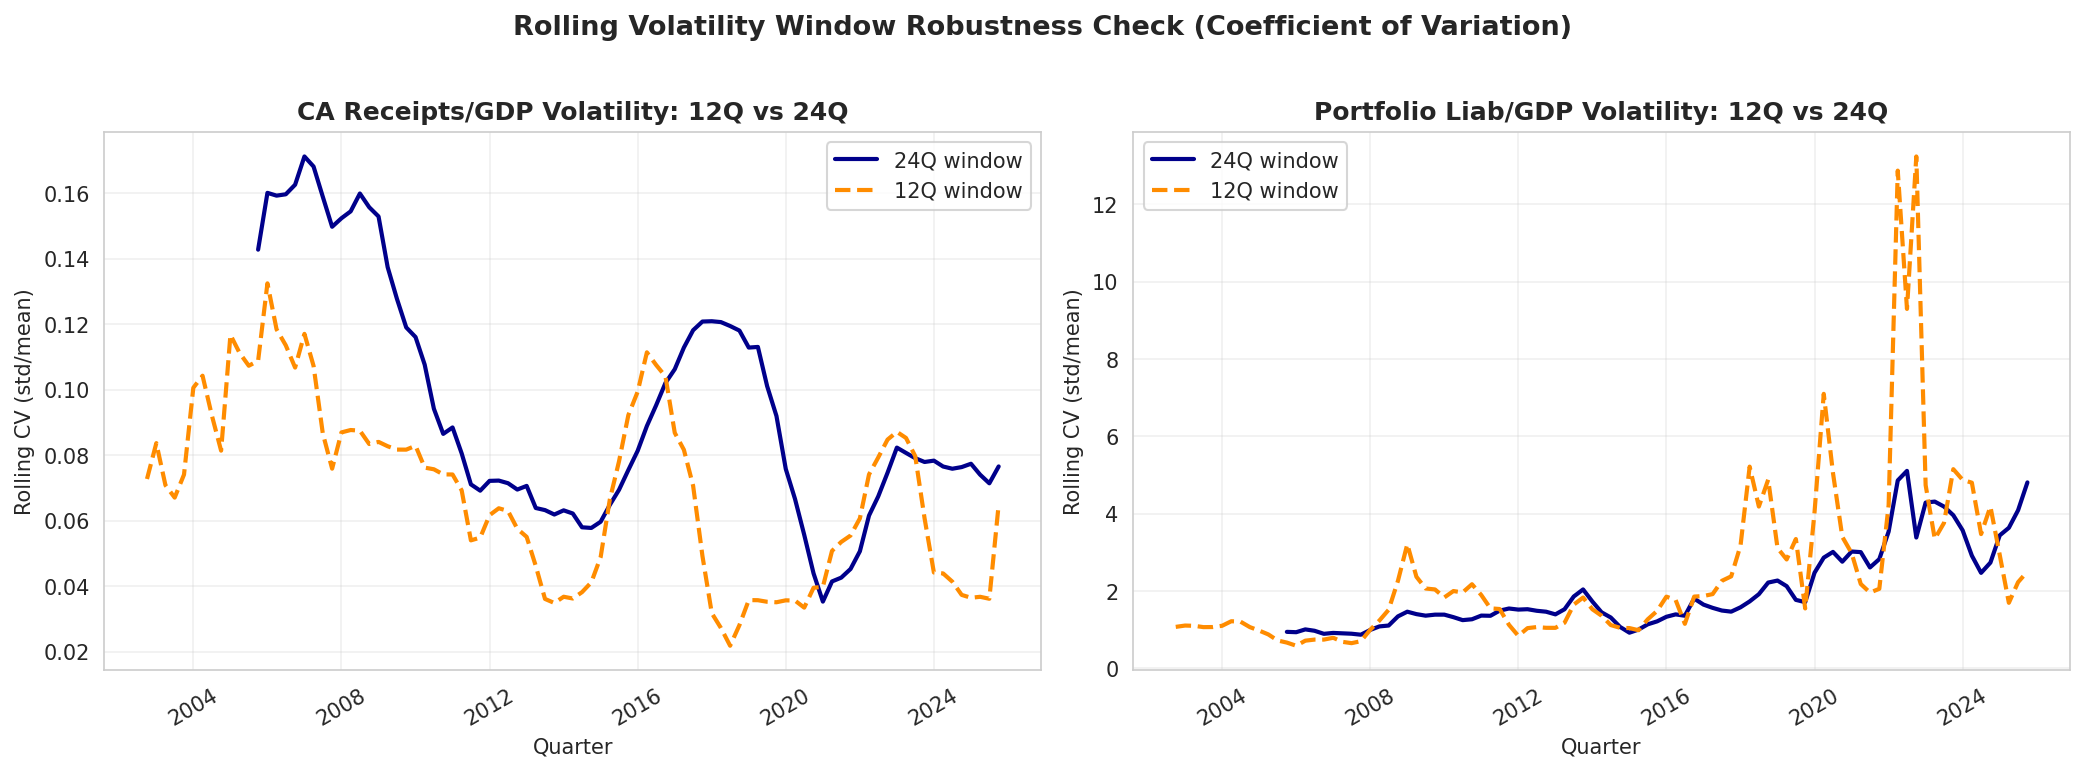

✓ Volatility robustness chart saved


In [ ]:
print('\n' + '=' * 80)
print('MINOR COMMENT 2: ROLLING WINDOW ROBUSTNESS — 12Q vs 24Q VOLATILITY (CV)')
print('=' * 80)

# Re-compute volatility with 12-quarter window using Coefficient of Variation (std/mean)
df['Volatility_CA_12Q']  = (df['CA_Receipts_GDP'].rolling(window=12).std() /
                            df['CA_Receipts_GDP'].rolling(window=12).mean())

df['Volatility_FPI_12Q'] = (df['Portfolio_Liab_GDP'].rolling(window=12).std() /
                            df['Portfolio_Liab_GDP'].rolling(window=12).mean())

# Re-run regression with 12Q volatility
X_cols_12q = [
    'Imports_GDP', 'NEER', 'Volatility_CA_12Q', 'Volatility_FPI_12Q',
    'M3_GDP', 'REER_Undervalued', 'Opportunity_Cost',
]
X_12q     = sm.add_constant(df[X_cols_12q])
mask_12q  = Y.notna() & X_12q.notna().all(axis=1)
model_12q = sm.OLS(Y[mask_12q], X_12q[mask_12q]).fit(cov_type='HC3')

# Comparison table
print(f'\n{"Variable":<35} {"24Q baseline":>14} {"12Q window":>12}')
print('-' * 63)
for var, label in zip(X_cols, X_cols_12q):
    b24 = model_demand.params.get(var, float('nan'))
    p24 = model_demand.pvalues.get(var, float('nan'))
    b12 = model_12q.params.get(label, float('nan'))
    p12 = model_12q.pvalues.get(label, float('nan'))
    print(f'  {label:<33} {b24:>8.4f} ({p24:.2f})  {b12:>8.4f} ({p12:.2f})')

print(f'\n  R² — 24Q window: {model_demand.rsquared:.4f}')
print(f'  R² — 12Q window: {model_12q.rsquared:.4f}')
print(f'  Obs — 24Q: {mask.sum()}   |   Obs — 12Q: {mask_12q.sum()}')

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts = df.index.to_timestamp()

axes[0].plot(ts, df['Volatility_CA'],    label='24Q window', lw=2, color='darkblue')
axes[0].plot(ts, df['Volatility_CA_12Q'], label='12Q window', lw=2,
             color='darkorange', ls='--')
axes[0].set_title('CA Receipts/GDP Volatility: 12Q vs 24Q', fontweight='bold')
axes[0].set_ylabel('Rolling CV (std/mean)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ts, df['Volatility_FPI'],    label='24Q window', lw=2, color='darkblue')
axes[1].plot(ts, df['Volatility_FPI_12Q'], label='12Q window', lw=2,
             color='darkorange', ls='--')
axes[1].set_title('Portfolio Liab/GDP Volatility: 12Q vs 24Q', fontweight='bold')
axes[1].set_ylabel('Rolling CV (std/mean)')
axes[1].legend()
axes[1].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Quarter')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Rolling Volatility Window Robustness Check (Coefficient of Variation)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('robustness_volatility_window.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Volatility robustness chart saved')

In [ ]:
print('\n' + '=' * 80)
print('PART 3: CRISIS DEFINITION (2000Q1–2025Q4) — FINAL v3')
print('=' * 80)

# ── Criterion 1: REER deviation below HP trend by > 1 S.D. ───────────────────
reer_dev_sd      = df['REER_Deviation'].std()
crisis_reer_dev  = (df['REER_Deviation'] < -1.0 * reer_dev_sd).astype(int)

# ── Criterion 2: Sharp quarterly reserve drawdown (< mean − 1.5 S.D.) ────────
df['Reserves_QoQ_Chg'] = df['Reserves_USD_Bn'].diff(1)
res_mean         = df['Reserves_QoQ_Chg'].mean()
res_sd           = df['Reserves_QoQ_Chg'].std()
crisis_res       = (df['Reserves_QoQ_Chg'] < res_mean - 1.5 * res_sd).astype(int)

# ── Criterion 3: Net FPI/GDP below mean − 0.75 S.D. ──────────────────────────
fpi_mean         = df['Net_FPI_GDP'].mean()
fpi_sd           = df['Net_FPI_GDP'].std()
crisis_fpi       = (df['Net_FPI_GDP'] < fpi_mean - 0.75 * fpi_sd).astype(int)

# ── Criterion 4: REER QoQ depreciation < −2% ─────────────────────────────────
df['REER_QoQ']   = df['REER'].pct_change(1) * 100
crisis_reer_qoq  = (df['REER_QoQ'] < -2.0).astype(int)

# ── Criterion 5: STED/Reserves ratio > mean + 1 S.D. (Guidotti pressure) ─────
df['STED_Reserves_Ratio'] = df['STED_USD_Bn'] / df['Reserves_USD_Bn']
sted_res_mean    = df['STED_Reserves_Ratio'].mean()
sted_res_sd      = df['STED_Reserves_Ratio'].std()
crisis_sted      = (df['STED_Reserves_Ratio'] > sted_res_mean + 1.0 * sted_res_sd).astype(int)

# ── Criterion 6: Large absolute portfolio outflow (USD bn) ───────────────────
df['Portfolio_Liab_QoQ_Chg'] = df['Portfolio_Liab_USD_Bn'].diff(1)
port_chg_mean    = df['Portfolio_Liab_QoQ_Chg'].mean()
port_chg_sd      = df['Portfolio_Liab_QoQ_Chg'].std()
crisis_port_abs  = (df['Portfolio_Liab_QoQ_Chg'] < port_chg_mean - 1.0 * port_chg_sd).astype(int)

# ── Composite score and dummy ─────────────────────────────────────────────────
df['Crisis_Score'] = (crisis_reer_dev + crisis_res + crisis_fpi
                      + crisis_reer_qoq + crisis_sted + crisis_port_abs)
df['Crisis']       = (df['Crisis_Score'] >= 2).astype(int)

print('Individual criterion counts (out of 104):')
print(f'  C1 – REER dev < −1 S.D.:              {crisis_reer_dev.sum():3d}  ({crisis_reer_dev.mean():.1%})')
print(f'  C2 – Reserve drop < mean−1.5σ:        {crisis_res.sum():3d}  ({crisis_res.mean():.1%})')
print(f'  C3 – Net FPI/GDP < mean−0.75σ:        {crisis_fpi.sum():3d}  ({crisis_fpi.mean():.1%})')
print(f'  C4 – REER QoQ < −2%:                  {crisis_reer_qoq.sum():3d}  ({crisis_reer_qoq.mean():.1%})')
print(f'  C5 – STED/Reserves > mean+1σ:         {crisis_sted.sum():3d}  ({crisis_sted.mean():.1%})')
print(f'  C6 – Portfolio outflow < mean−1σ:     {crisis_port_abs.sum():3d}  ({crisis_port_abs.mean():.1%})')

# ── Episode clustering ────────────────────────────────────────────────────────
# Consecutive crisis quarters = one episode (standard in EMP literature)
# A new episode starts only after ≥ 2 non-crisis quarters (tranquil window)
TRANQUIL_WINDOW = 2

episodes   = []
in_episode = False
ep_start   = None
tranquil   = 0

for period, row in df[['Crisis']].iterrows():
    if row['Crisis'] == 1:
        tranquil = 0
        if not in_episode:
            in_episode = True
            ep_start   = period
    else:
        if in_episode:
            tranquil += 1
            if tranquil >= TRANQUIL_WINDOW:
                episodes.append((ep_start, period - tranquil))
                in_episode = False
                tranquil   = 0

if in_episode:   # close any open episode at end of sample
    episodes.append((ep_start, df.index[-1]))

print(f'\nRaw crisis quarters:  {df["Crisis"].sum()} / {len(df)}  ({df["Crisis"].mean():.1%})')
print(f'Distinct episodes:    {len(episodes)}')
print('\nEpisode list:')
for i, (s, e) in enumerate(episodes, 1):
    quarters_in = df.loc[s:e, 'Crisis'].sum()
    peak_q      = df.loc[s:e, 'Crisis_Score'].idxmax()
    peak_s      = int(df.loc[peak_q, 'Crisis_Score'])
    print(f'  Episode {i}: {s} → {e}  '
          f'({quarters_in} crisis qtrs, peak score {peak_s}/6 at {peak_q})')

# ── Sanity check ──────────────────────────────────────────────────────────────
known = {
    "Dot-com '00": '2000Q4',
    'GFC 2008':    '2008Q4',
    'Taper 2013':  '2013Q3',
    'COVID 2020':  '2020Q1',   # onset Q1, not Q2
    'Rate Shock':  '2022Q1',   # onset Q1 2022
}
print('\nSanity check — known episodes (onset quarter):')
for ep, q in known.items():
    p     = pd.Period(q, freq='Q')
    score = int(df.loc[p, 'Crisis_Score'])
    flag  = '✓ FLAGGED' if df.loc[p, 'Crisis'] == 1 else '✗ missed'
    c1 = int(crisis_reer_dev.loc[p]); c2 = int(crisis_res.loc[p])
    c3 = int(crisis_fpi.loc[p]);      c4 = int(crisis_reer_qoq.loc[p])
    c5 = int(crisis_sted.loc[p]);     c6 = int(crisis_port_abs.loc[p])
    print(f'  {ep:18s} ({q}): score={score}/6  '
          f'[C1={c1} C2={c2} C3={c3} C4={c4} C5={c5} C6={c6}]  {flag}')

# ── Thesis note ───────────────────────────────────────────────────────────────
print(f"""
Methodological note:
  {df['Crisis'].sum()} crisis quarters ({df['Crisis'].mean():.1%}) identified across
  {len(episodes)} distinct stress episodes using a 6-criterion composite EMP index
  (≥2 of 6 must fire simultaneously). Consecutive flagged quarters are clustered
  into episodes separated by ≥2 tranquil quarters, following Laeven & Valencia
  (2012). Crisis onset dates are used for the sanity check — COVID stress began
  in 2020Q1 (capital flight, reserve drawdown) before 2020Q2 recovery; Rate Shock
  stress peaked at 2022Q1 onset before gradual INR depreciation through Q3.
""")


PART 3: CRISIS DEFINITION (2000Q1–2025Q4) — FINAL v3
Individual criterion counts (out of 104):
  C1 – REER dev < −1 S.D.:               16  (15.4%)
  C2 – Reserve drop < mean−1.5σ:          6  (5.8%)
  C3 – Net FPI/GDP < mean−0.75σ:         20  (19.2%)
  C4 – REER QoQ < −2%:                   16  (15.4%)
  C5 – STED/Reserves > mean+1σ:          13  (12.5%)
  C6 – Portfolio outflow < mean−1σ:      15  (14.4%)

Raw crisis quarters:  24 / 104  (23.1%)
Distinct episodes:    11

Episode list:
  Episode 1: 2006Q2 → 2006Q2  (1 crisis qtrs, peak score 2/6 at 2006Q2)
  Episode 2: 2008Q1 → 2009Q1  (5 crisis qtrs, peak score 3/6 at 2008Q1)
  Episode 3: 2011Q4 → 2012Q2  (2 crisis qtrs, peak score 5/6 at 2012Q2)
  Episode 4: 2013Q2 → 2014Q2  (5 crisis qtrs, peak score 4/6 at 2013Q3)
  Episode 5: 2016Q1 → 2016Q1  (1 crisis qtrs, peak score 2/6 at 2016Q1)
  Episode 6: 2016Q4 → 2016Q4  (1 crisis qtrs, peak score 2/6 at 2016Q4)
  Episode 7: 2018Q2 → 2018Q2  (1 crisis qtrs, peak score 2/6 at 2018Q2)
  

In [ ]:
print('\n' + '=' * 80)
print('ROBUSTNESS CHECK: STRICTER THRESHOLD (score ≥ 3 of 6)')
print('=' * 80)

df['Crisis_Strict'] = (df['Crisis_Score'] >= 3).astype(int)

print(f'Strict crisis quarters: {df["Crisis_Strict"].sum()} / {len(df)} '
      f'({df["Crisis_Strict"].mean():.1%})')

known = {
    'GFC 2008':   '2008Q4',
    'Taper 2013': '2013Q3',
    'COVID 2020': '2020Q1',
    'Rate Shock': '2022Q1',
}
print('\nSanity check — strict threshold:')
for ep, q in known.items():
    p    = pd.Period(q, freq='Q')
    flag = '✓' if df.loc[p, 'Crisis_Strict'] == 1 else '✗'
    print(f'  {ep:18s} ({q}): score={int(df.loc[p,"Crisis_Score"])}/6  {flag}')

print('\nStrict crisis quarters:')
strict_df = df[df['Crisis_Strict'] == 1][['Crisis_Score','REER_Deviation',
                                           'Reserves_QoQ_Chg','Net_FPI_GDP']]
print(strict_df.to_string())


ROBUSTNESS CHECK: STRICTER THRESHOLD (score ≥ 3 of 6)
Strict crisis quarters: 9 / 104 (8.7%)

Sanity check — strict threshold:
  GFC 2008           (2008Q4): score=3/6  ✓
  Taper 2013         (2013Q3): score=4/6  ✓
  COVID 2020         (2020Q1): score=2/6  ✗
  Rate Shock         (2022Q1): score=3/6  ✓

Strict crisis quarters:
        Crisis_Score  REER_Deviation  Reserves_QoQ_Chg  Net_FPI_GDP
tq                                                                 
2008Q1             3        0.332110            32.696    -0.003904
2008Q2             3       -4.322352             3.195    -0.004291
2008Q3             3       -5.304807           -25.108    -0.001356
2008Q4             3       -5.780994           -30.288    -0.006851
2012Q2             5       -4.377522            -3.399    -0.001453
2013Q3             4       -8.409765            -5.428    -0.004950
2022Q1             3       -0.447879           -29.451    -0.005974
2024Q4             3        5.108463           -70.480    -

In [ ]:
print('\n' + '=' * 80)
print('PART 4: RESERVE DEMAND REGRESSION + DIAGNOSTICS')
print('=' * 80)

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.tsa.stattools import adfuller

Y = df['Reserves_GDP']   # decimal ratio throughout — fixes Minor Comment 6

X_cols = [
    'Imports_GDP',
    'NEER',
    'Volatility_CA',
    'Volatility_FPI',
    'M3_GDP',
    'REER_Undervalued',
    'Opportunity_Cost',
]

X      = sm.add_constant(df[X_cols])
mask   = Y.notna() & X.notna().all(axis=1)
Y_fit  = Y[mask]
X_fit  = X[mask]

model_demand = sm.OLS(Y_fit, X_fit).fit(cov_type='HC3')
resid_sd     = model_demand.resid.std()

df.loc[Y_fit.index, 'Reserves_Fitted'] = model_demand.fittedvalues
df.loc[Y_fit.index, 'Reserves_Resid']  = model_demand.resid

print(model_demand.summary())
print(f'\nResidual S.D.: {resid_sd:.4f}   |   R²: {model_demand.rsquared:.4f}')

# ── Stationarity: ADF on dependent variable ───────────────────────────────────
print('\n--- ADF Unit Root Tests ---')
for var in [Y] + [df[c] for c in X_cols]:
    s = var.dropna()
    try:
        adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
        status = 'stationary' if adf_p < 0.05 else 'NON-STATIONARY'
        print(f'  {s.name:<25}  ADF={adf_stat:7.3f}  p={adf_p:.3f}  → {status}')
    except Exception as e:
        print(f'  {s.name:<25}  ERROR: {e}')

# ── Serial correlation: Breusch-Godfrey ──────────────────────────────────────
print('\n--- Breusch-Godfrey Serial Correlation Test (up to 4 lags) ---')
bg_lm, bg_p, bg_f, bg_fp = acorr_breusch_godfrey(model_demand, nlags=4)
print(f'  LM statistic: {bg_lm:.4f}   p-value: {bg_p:.4f}')
if bg_p < 0.05:
    print('  ⚠ Serial correlation detected — consider lagged DV specification below')
else:
    print('  ✓ No significant serial correlation')

# ── Durbin-Watson ─────────────────────────────────────────────────────────────
dw = durbin_watson(model_demand.resid)
print(f'  Durbin-Watson statistic: {dw:.4f}  (2.0 = no autocorrelation)')

# ── Lagged DV specification ───────────────────────────────────────────────────
print('\n--- Lagged DV Specification (robustness) ---')
df['Reserves_GDP_L1'] = df['Reserves_GDP'].shift(1)
X_cols_ldv = X_cols + ['Reserves_GDP_L1']
X_ldv      = sm.add_constant(df[X_cols_ldv])
mask_ldv   = Y.notna() & X_ldv.notna().all(axis=1)
model_ldv  = sm.OLS(Y[mask_ldv], X_ldv[mask_ldv]).fit(cov_type='HC3')

print(f'  Baseline R²:      {model_demand.rsquared:.4f}')
print(f'  Lagged-DV R²:     {model_ldv.rsquared:.4f}')
print(f'  Lagged DV coeff:  {model_ldv.params["Reserves_GDP_L1"]:.4f}  '
      f'(p={model_ldv.pvalues["Reserves_GDP_L1"]:.3f})')
print('  Other coefficients:')
for var in X_cols:
    b_base = model_demand.params.get(var, float('nan'))
    b_ldv  = model_ldv.params.get(var, float('nan'))
    print(f'    {var:<30} baseline={b_base:8.4f}   with-LDV={b_ldv:8.4f}')


PART 4: RESERVE DEMAND REGRESSION + DIAGNOSTICS
                            OLS Regression Results                            
Dep. Variable:           Reserves_GDP   R-squared:                       0.685
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     20.82
Date:                Fri, 17 Apr 2026   Prob (F-statistic):           4.11e-15
Time:                        20:48:46   Log-Likelihood:                 115.24
No. Observations:                  81   AIC:                            -214.5
Df Residuals:                      73   BIC:                            -195.3
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------

In [ ]:
# Full-spec model for Chart 1 (all regressors available 2000Q1–2025Q4)
X_full_cols = [
    'M3_GDP', 'Imports_GDP', 'NEER', 'REER',
    'Opportunity_Cost', 'STED_USD_Bn', 'Portfolio_Liab_GDP'
]
X_full = sm.add_constant(df[X_full_cols])
mask_f = Y.notna() & X_full.notna().all(axis=1)
model_full = sm.OLS(Y[mask_f], X_full[mask_f]).fit(cov_type='HC3')

df['Reserves_Fitted_Full'] = model_full.predict(X_full)
resid_sd_full = model_full.resid.std()

df['Reserves_Upper_3SD'] = df['Reserves_Fitted_Full'] + 3 * resid_sd_full
df['Reserves_Lower_3SD'] = df['Reserves_Fitted_Full'] - 3 * resid_sd_full

print('Full-sample reserve demand model estimated.')
print(f'R²: {model_full.rsquared:.4f}  |  Resid SD: {resid_sd_full:.4f}')
print(f'Sample: {df.index[mask_f][0]} – {df.index[mask_f][-1]}')

Full-sample reserve demand model estimated.
R²: 0.7720  |  Resid SD: 0.0640
Sample: 2000Q1 – 2025Q4



PART 5: CHART 1 — RESERVE DEMAND ESTIMATION  (2000Q1–2025Q4)


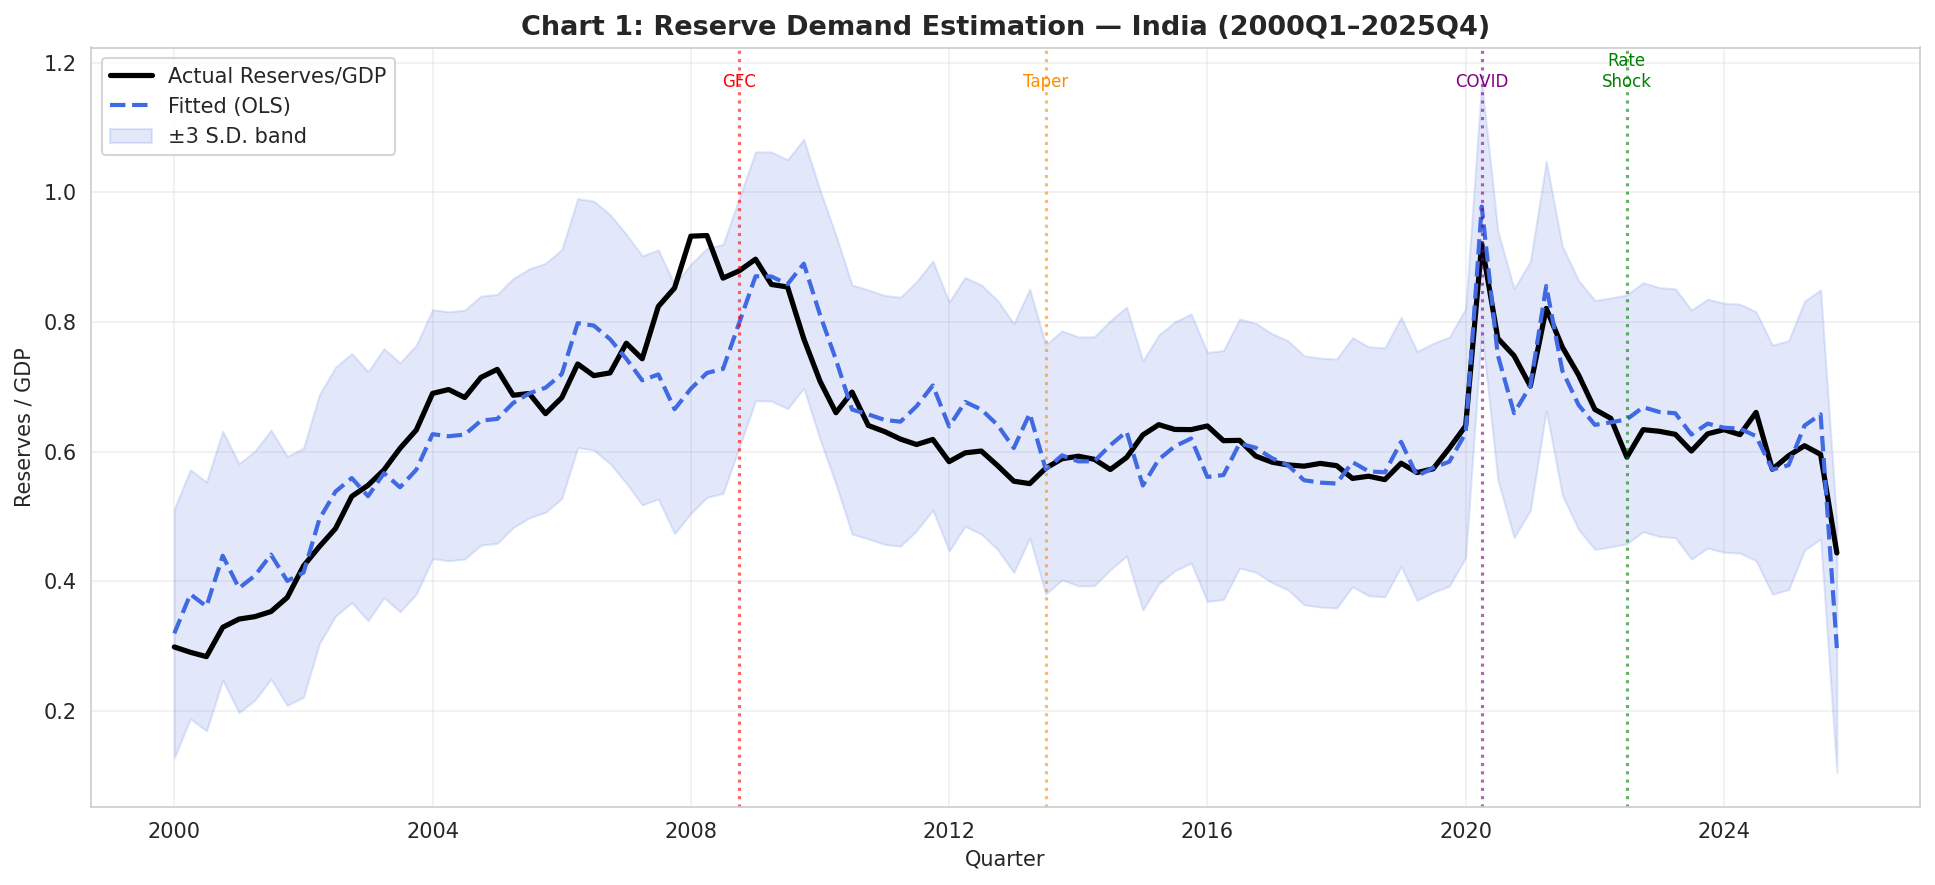

✓ Chart 1 saved


In [ ]:
print('\n' + '=' * 80)
print('PART 5: CHART 1 — RESERVE DEMAND ESTIMATION  (2000Q1–2025Q4)')
print('=' * 80)

fig, ax = plt.subplots(figsize=(13, 6))
ts = df.index.to_timestamp()

ax.plot(ts, df['Reserves_GDP'],         label='Actual Reserves/GDP',
        linewidth=2.5, color='black')
ax.plot(ts, df['Reserves_Fitted_Full'], label='Fitted (OLS)',
        linewidth=2, linestyle='--', color='royalblue')
ax.fill_between(ts, df['Reserves_Upper_3SD'], df['Reserves_Lower_3SD'],
                alpha=0.15, color='royalblue', label='±3 S.D. band')

events = {
    '2008Q4': ('GFC',        'red'),
    '2013Q3': ('Taper',      'darkorange'),
    '2020Q2': ('COVID',      'purple'),
    '2022Q3': ('Rate\nShock','green'),
}
for qstr, (lbl, col) in events.items():
    t = pd.Period(qstr, freq='Q').to_timestamp()
    ax.axvline(t, color=col, linestyle=':', alpha=0.6, linewidth=1.5)
    ax.text(t, ax.get_ylim()[1] * 0.95, lbl, color=col, fontsize=8, ha='center')

ax.set_title('Chart 1: Reserve Demand Estimation — India (2000Q1–2025Q4)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Reserves / GDP')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart1_reserve_demand.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Chart 1 saved')

In [ ]:
print('\n' + '=' * 80)
print('PART 6: IMF ARA METRIC (EM WEIGHTS)')
print('=' * 80)

# ARA = 0.30×STED + 0.10×OPL + 0.05×M3 + 0.05×Exports  (all in USD bn)
df['ARA_Metric_USD'] = (
    0.30 * df['STED_USD_Bn']
    + 0.10 * df['OPL_USD_Bn']
    + 0.05 * df['M3_USD_Bn']
    + 0.05 * df['Exports_USD_Bn']
)
df['ARA_Ratio']     = df['Reserves_USD_Bn'] / df['ARA_Metric_USD']
df['ARA_Lower_USD'] = 1.00 * df['ARA_Metric_USD']   # 100% threshold
df['ARA_Upper_USD'] = 1.50 * df['ARA_Metric_USD']   # 150% threshold

print(df[['Reserves_USD_Bn', 'ARA_Metric_USD', 'ARA_Ratio']].describe().round(3))
print(f'\nARA ratio — current ({df.index[-1]}): {df["ARA_Ratio"].iloc[-1]:.2f}')
print(f'Quarters below 100% ARA threshold: '
      f'{(df["ARA_Ratio"] < 1).sum()} / {df["ARA_Ratio"].notna().sum()}')


PART 6: IMF ARA METRIC (EM WEIGHTS)
       Reserves_USD_Bn  ARA_Metric_USD  ARA_Ratio
count          104.000         104.000    104.000
mean           306.117          57.181      5.780
std            173.523          33.885      1.345
min             32.604           7.116      3.812
25%            158.510          21.931      4.732
50%            282.251          65.445      5.411
75%            405.913          85.488      7.028
max            640.033         110.778      9.444

ARA ratio — current (2025Q4): 5.33
Quarters below 100% ARA threshold: 0 / 104



PART 7: CHARTS 2–5 — COMPARATIVE ADEQUACY METRICS


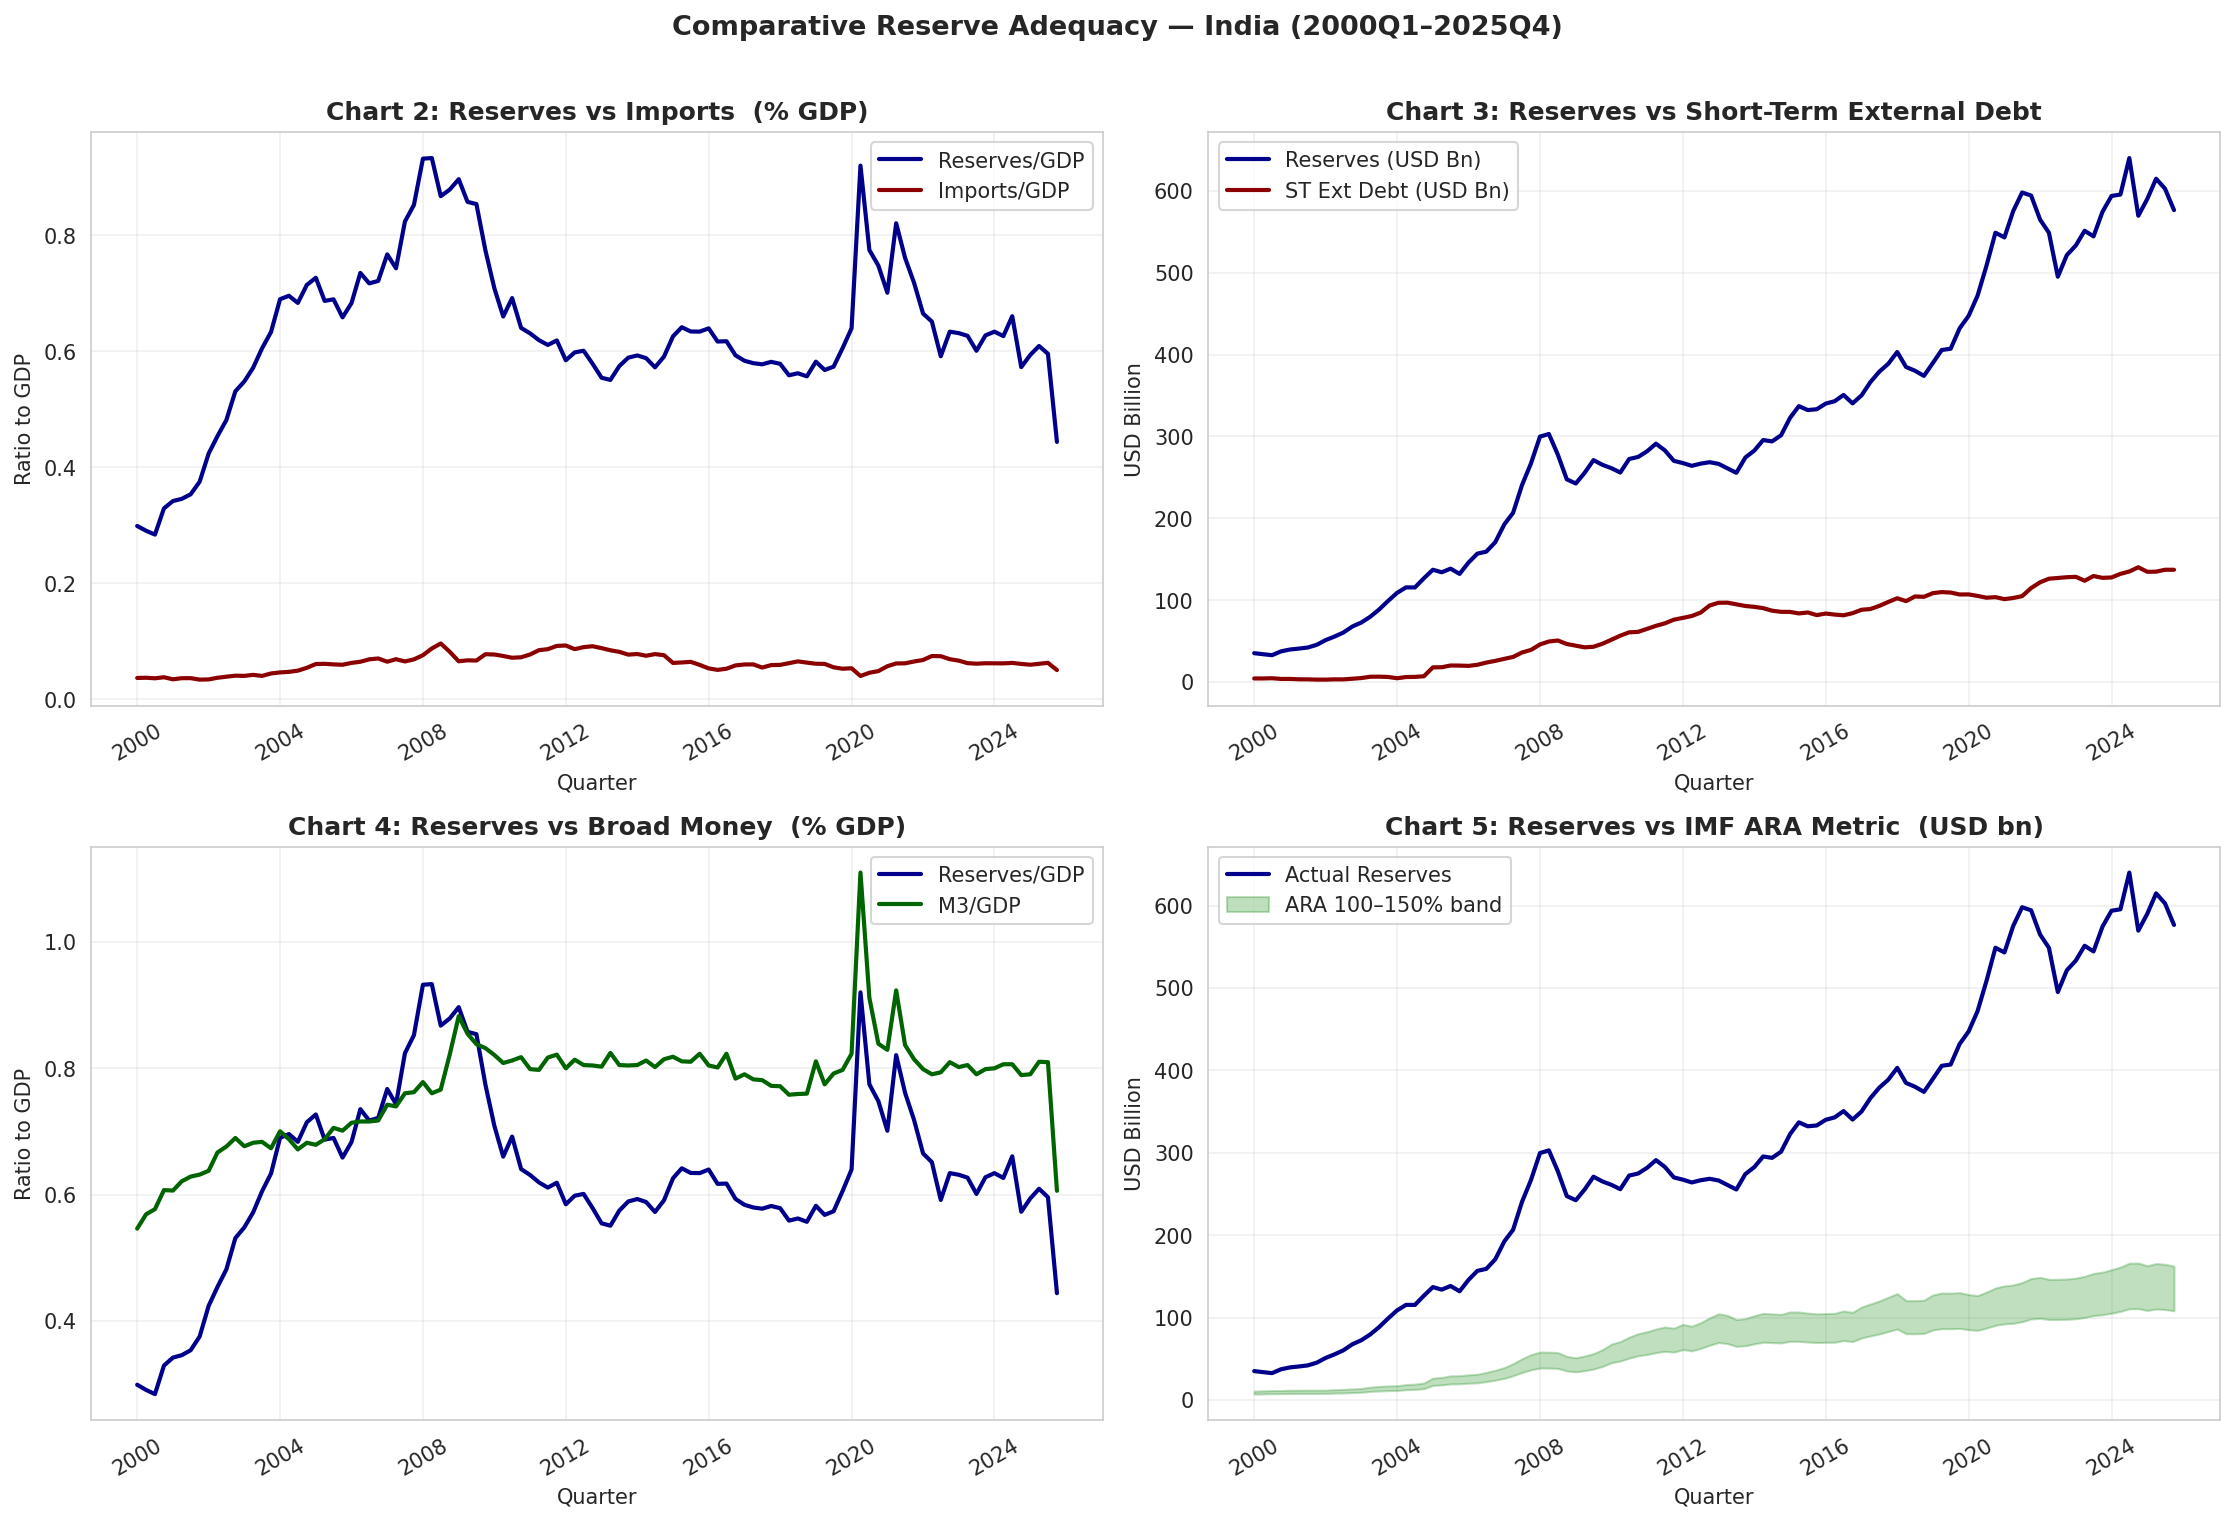

✓ Charts 2–5 saved


In [ ]:
print('\n' + '=' * 80)
print('PART 7: CHARTS 2–5 — COMPARATIVE ADEQUACY METRICS')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
ts = df.index.to_timestamp()

# Chart 2 – Reserves vs Imports (% GDP)
ax = axes[0, 0]
ax.plot(ts, df['Reserves_GDP'], label='Reserves/GDP', lw=2, color='darkblue')
ax.plot(ts, df['Imports_GDP'],  label='Imports/GDP',  lw=2, color='darkred')
ax.set_title('Chart 2: Reserves vs Imports  (% GDP)', fontweight='bold')
ax.set_ylabel('Ratio to GDP'); ax.legend(); ax.grid(alpha=0.3)

# Chart 3 – Reserves vs Short-Term External Debt (USD bn)
ax = axes[0, 1]
ax.plot(ts, df['Reserves_USD_Bn'], label='Reserves (USD Bn)',    lw=2, color='darkblue')
ax.plot(ts, df['STED_USD_Bn'],     label='ST Ext Debt (USD Bn)', lw=2, color='darkred')
ax.set_title('Chart 3: Reserves vs Short-Term External Debt', fontweight='bold')
ax.set_ylabel('USD Billion'); ax.legend(); ax.grid(alpha=0.3)

# Chart 4 – Reserves vs Broad Money (% GDP)
ax = axes[1, 0]
ax.plot(ts, df['Reserves_GDP'], label='Reserves/GDP', lw=2, color='darkblue')
ax.plot(ts, df['M3_GDP'],       label='M3/GDP',       lw=2, color='darkgreen')
ax.set_title('Chart 4: Reserves vs Broad Money  (% GDP)', fontweight='bold')
ax.set_ylabel('Ratio to GDP'); ax.legend(); ax.grid(alpha=0.3)

# Chart 5 – IMF ARA ratio with 100%–150% band
ax = axes[1, 1]
ax.plot(ts, df['Reserves_USD_Bn'], label='Actual Reserves', lw=2, color='darkblue')
ax.fill_between(ts, df['ARA_Lower_USD'], df['ARA_Upper_USD'],
                alpha=0.25, color='green', label='ARA 100–150% band')
ax.set_title('Chart 5: Reserves vs IMF ARA Metric  (USD bn)', fontweight='bold')
ax.set_ylabel('USD Billion'); ax.legend(); ax.grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Quarter')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Comparative Reserve Adequacy — India (2000Q1–2025Q4)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts2_5_comparative_adequacy.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Charts 2–5 saved')

In [ ]:
print('\n' + '=' * 80)
print('PART 8: PROBIT MODEL — CRISIS PROBABILITY (ADJUSTED FOR QUARTERLY DATA)')
print('=' * 80)

Y_crisis = df['Crisis']

# 1. Create the specific variables requested by Das & Nath (2015)
df['REER_Overval'] = df['REER_Deviation']
df['Fin_Openness'] = df['Net_FPI_GDP'].abs()
df['Ext_Liab_M3'] = df['STED_USD_Bn'] / df['M3_USD_Bn']

# 2. MATCHING ANNUAL METHODOLOGY: Take the average of the 1-year (4q) and 2-year (8q) lags
for col in ['REER_Overval', 'Fin_Openness', 'Ext_Liab_M3']:
    df[f'{col}_LagAvg'] = (df[col].shift(4) + df[col].shift(8)) / 2

# 3. Set up the Probit model
X_probit_cols = [
    'REER_Overval_LagAvg',
    'Fin_Openness_LagAvg',
    'Ext_Liab_M3_LagAvg'
]

X_probit = sm.add_constant(df[X_probit_cols])
mask_p   = Y_crisis.notna() & X_probit.notna().all(axis=1)
Y_p, X_p = Y_crisis[mask_p], X_probit[mask_p]

probit_model = sm.Probit(Y_p, X_p).fit(disp=False)

# Fill probabilities back into the dataframe
df['Crisis_Prob'] = np.nan
df.loc[Y_p.index, 'Crisis_Prob'] = probit_model.predict(X_p)

# 4. SMOOTHING: 3-year moving average (12 quarters) as specified in Das & Nath
df['Crisis_Prob_Smoothed'] = df['Crisis_Prob'].rolling(window=12, min_periods=1).mean()

print('\n' + '=' * 80)
print('TABLE 3: PROBIT MODEL RESULTS')
print('=' * 80)
print(probit_model.summary())
print(f'\nMean crisis probability (Smoothed): {df["Crisis_Prob_Smoothed"].mean():.2%}')


PART 8: PROBIT MODEL — CRISIS PROBABILITY (ADJUSTED FOR QUARTERLY DATA)

TABLE 3: PROBIT MODEL RESULTS
                          Probit Regression Results                           
Dep. Variable:                 Crisis   No. Observations:                   96
Model:                         Probit   Df Residuals:                       92
Method:                           MLE   Df Model:                            3
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                 0.06942
Time:                        20:49:32   Log-Likelihood:                -50.237
converged:                       True   LL-Null:                       -53.984
Covariance Type:            nonrobust   LLR p-value:                   0.05768
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.9470      0.608     -3.202      0.001      -3.139      -0.755



PART 9: CHART 6 — SMOOTHED PROBABILITY OF EXTERNAL CRISIS (Ref: Figure 9)


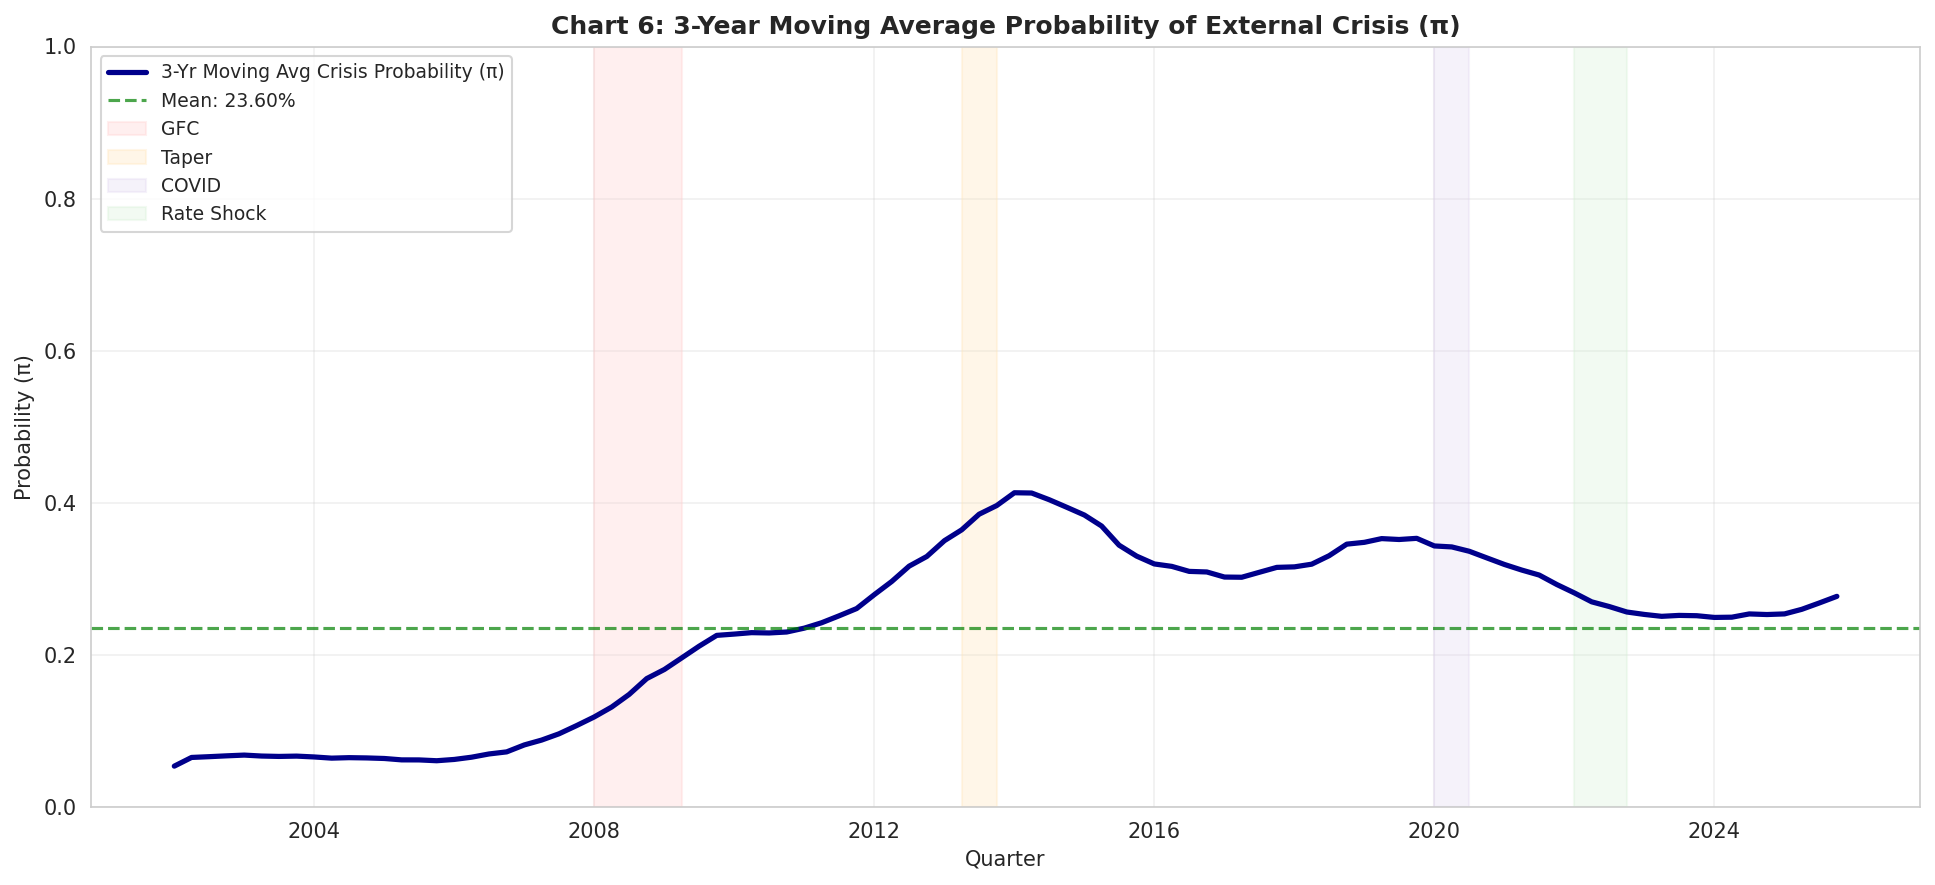

In [ ]:
print('\n' + '=' * 80)
print('PART 9: CHART 6 — SMOOTHED PROBABILITY OF EXTERNAL CRISIS (Ref: Figure 9)')
print('=' * 80)

fig, ax = plt.subplots(figsize=(13, 6))
ts = df.index.to_timestamp()

# Plot the SMOOTHED probability
ax.plot(ts, df['Crisis_Prob_Smoothed'], lw=2.5, color='darkblue',
        label='3-Yr Moving Avg Crisis Probability (π)')

ax.axhline(df['Crisis_Prob_Smoothed'].mean(), color='green', linestyle='--', alpha=0.7,
           label=f'Mean: {df["Crisis_Prob_Smoothed"].mean():.2%}')

episodes = [
    ('2008Q1', '2009Q2', 'GFC',        '#ffcccc'),
    ('2013Q2', '2013Q4', 'Taper',      '#ffe4b5'),
    ('2020Q1', '2020Q3', 'COVID',      '#e0d4f0'),
    ('2022Q1', '2022Q4', 'Rate Shock', '#d4f0d4'),
]
for qs, qe, lbl, col in episodes:
    t1 = pd.Period(qs, 'Q').to_timestamp()
    t2 = pd.Period(qe, 'Q').to_timestamp()
    ax.axvspan(t1, t2, alpha=0.3, color=col, label=lbl)

ax.set_title('Chart 6: 3-Year Moving Average Probability of External Crisis (π)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Probability (π)')
ax.set_ylim([0, max(df['Crisis_Prob_Smoothed'].max() + 0.1, 1)])
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


PART 11: HP-FILTER EXTREME STRESS SCENARIOS (2000Q1–2025Q4)


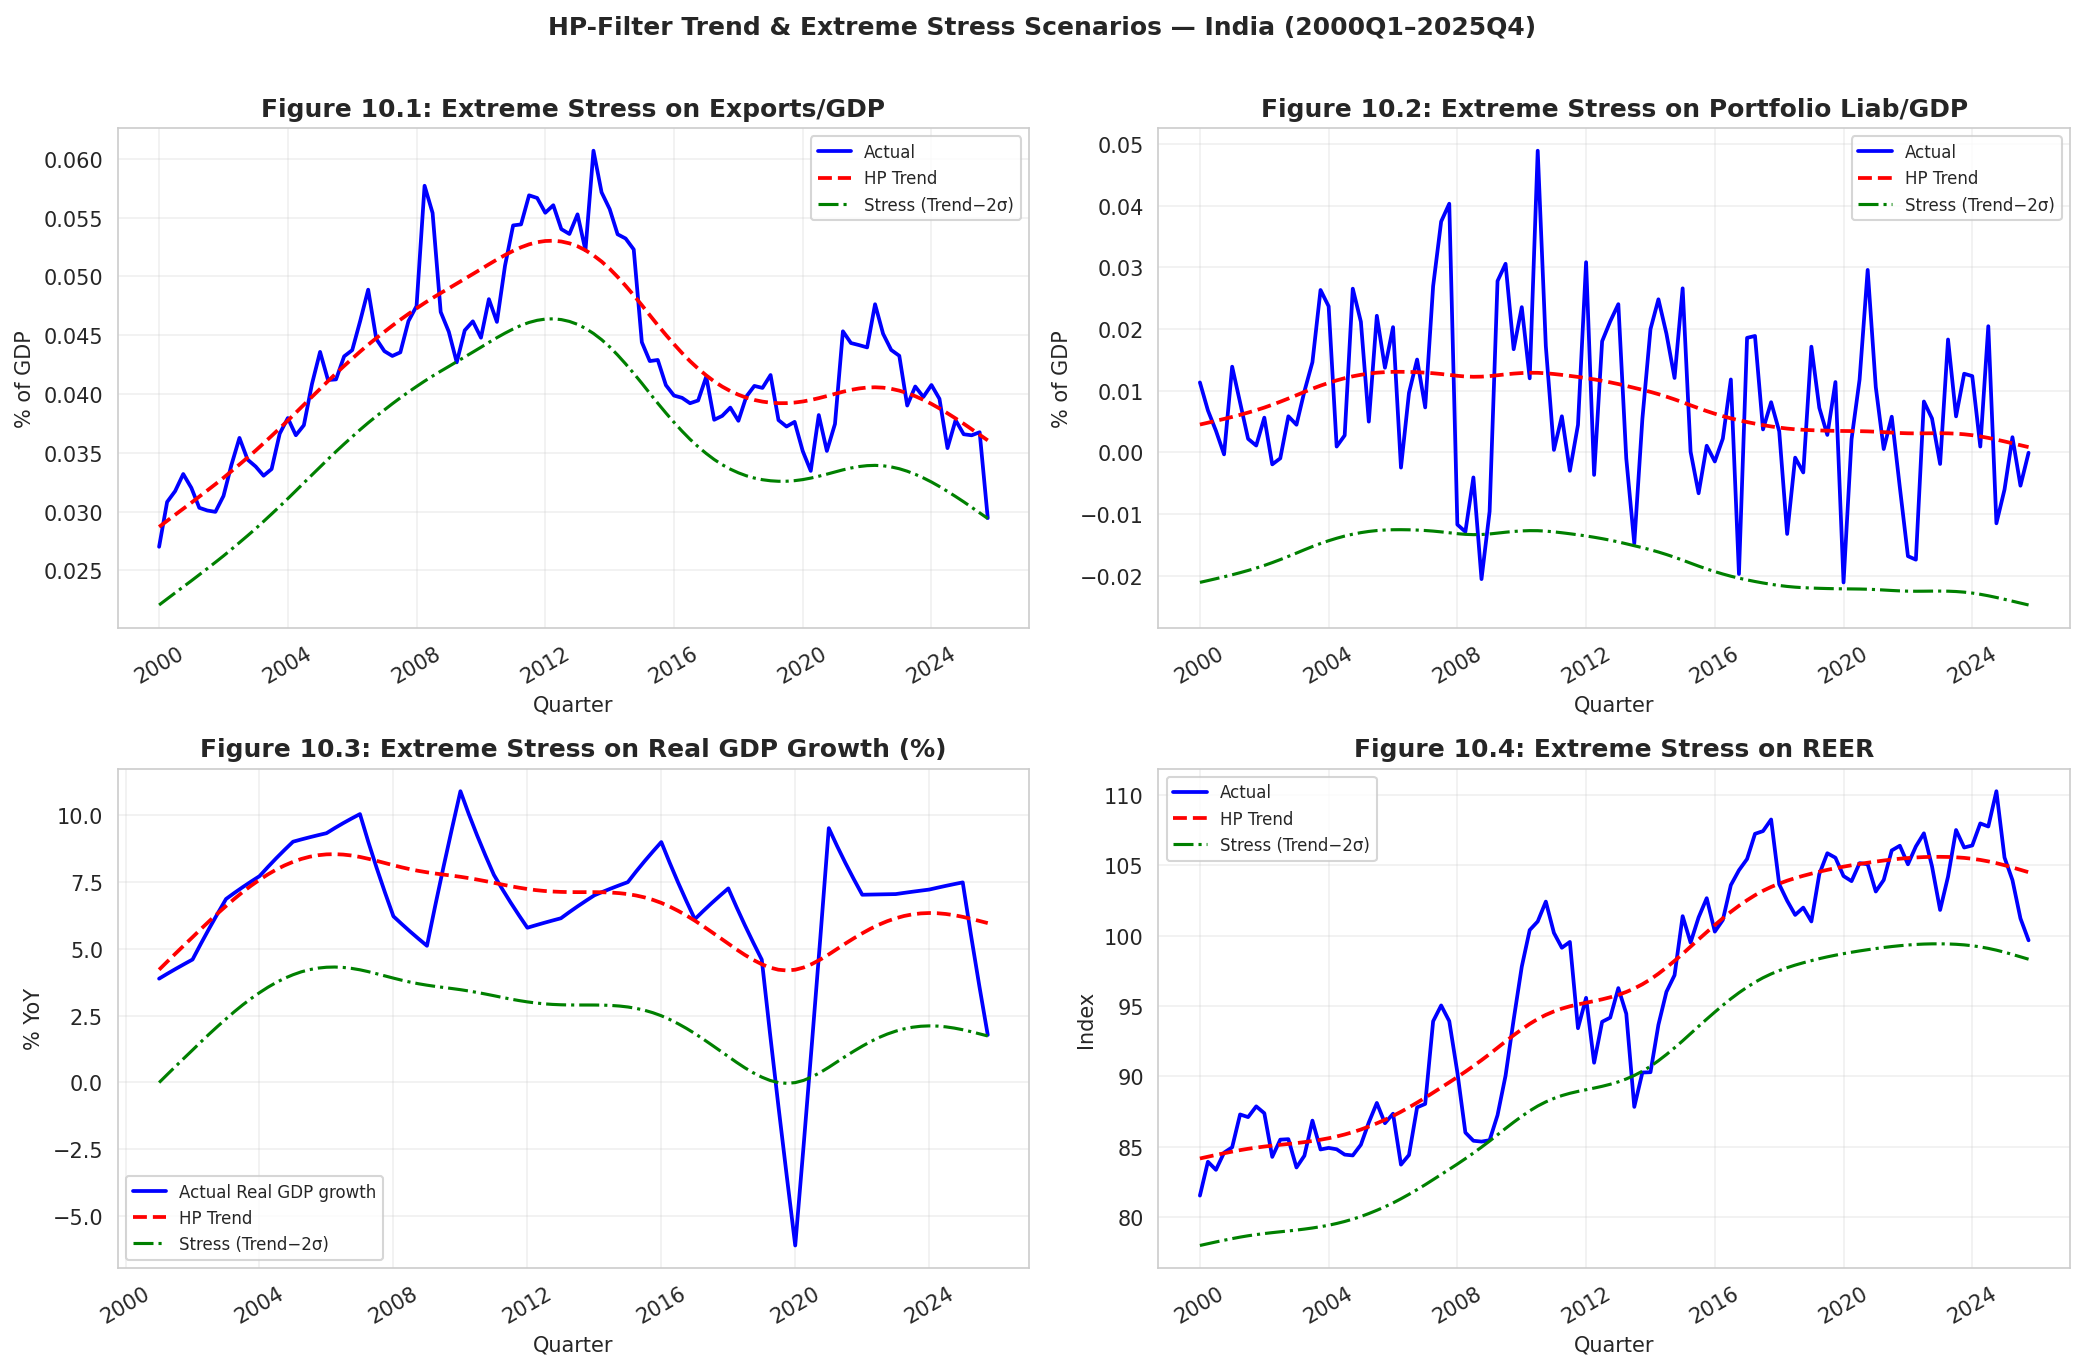

✓ Figure 10 saved


In [ ]:
print('\n' + '=' * 80)
print('PART 11: HP-FILTER EXTREME STRESS SCENARIOS (2000Q1–2025Q4)')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ts = df.index.to_timestamp()

def plot_hp_panel(ax, series, title, ylabel):
    s = series.astype(float)
    cyc, trend = hpfilter(s, lamb=1600)
    sigma = cyc.std()
    ax.plot(ts[:len(s)], s,              label='Actual',            color='blue',  lw=1.8)
    ax.plot(ts[:len(s)], trend,          label='HP Trend',          color='red',   lw=1.8, ls='--')
    ax.plot(ts[:len(s)], trend-2*sigma,  label='Stress (Trend−2σ)', color='green', lw=1.5, ls='-.')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    return trend, sigma

plot_hp_panel(axes[0,0], df['Exports_GDP'],
              'Figure 10.1: Extreme Stress on Exports/GDP', '% of GDP')

plot_hp_panel(axes[0,1], df['Portfolio_Liab_GDP'],
              'Figure 10.2: Extreme Stress on Portfolio Liab/GDP', '% of GDP')

# Real GDP growth panel (YoY)
gdp_gr = df['Real_GDP_USD_Bn'].pct_change(4).dropna() * 100
cyc_g, trend_g = hpfilter(gdp_gr.values, lamb=1600)
sigma_g = cyc_g.std()
ts_g = gdp_gr.index.to_timestamp()
axes[1,0].plot(ts_g, gdp_gr,            label='Actual Real GDP growth', color='blue',  lw=1.8)
axes[1,0].plot(ts_g, trend_g,           label='HP Trend',               color='red',   lw=1.8, ls='--')
axes[1,0].plot(ts_g, trend_g-2*sigma_g, label='Stress (Trend−2σ)',      color='green', lw=1.5, ls='-.')
axes[1,0].set_title('Figure 10.3: Extreme Stress on Real GDP Growth (%)', fontweight='bold')
axes[1,0].set_ylabel('% YoY'); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

plot_hp_panel(axes[1,1], df['REER'],
              'Figure 10.4: Extreme Stress on REER', 'Index')

for ax in axes.flat:
    ax.set_xlabel('Quarter')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('HP-Filter Trend & Extreme Stress Scenarios — India (2000Q1–2025Q4)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_hp_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Figure 10 saved')

In [ ]:
# If you are in Colab and don't have pandas_datareader, uncomment the next line to install it:
# !pip install pandas-datareader

import pandas_datareader.data as web
import datetime

print('\n' + '=' * 80)
print('PART 9.5: FETCHING US YIELD DATA FOR TERM PREMIUM (δ) CALCULATION')
print('=' * 80)

# Define the timeframe matching your dataset
start_date = '2000-01-01'
end_date = '2025-12-31'

try:
    print("Fetching US 10-Year Treasury and Federal Funds rates from FRED...")
    # GS10: 10-Year Treasury Constant Maturity Rate
    # FEDFUNDS: Effective Federal Funds Rate
    us_rates = web.DataReader(['GS10', 'FEDFUNDS'], 'fred', start_date, end_date)

    # Calculate the spread (Term Premium in percentage)
    us_rates['Term_Premium'] = us_rates['GS10'] - us_rates['FEDFUNDS']

    # Calculate the average spread over the 2000-2025 period
    avg_term_premium_pct = us_rates['Term_Premium'].mean()

    # Convert percentage to decimal for the J&R model (δ)
    calculated_delta = avg_term_premium_pct / 100.0

    print(f"Average 10-Year US Treasury Yield (2000-2025): {us_rates['GS10'].mean():.2f}%")
    print(f"Average Federal Funds Rate (2000-2025):        {us_rates['FEDFUNDS'].mean():.2f}%")
    print(f"Average Spread (Term Premium):                 {avg_term_premium_pct:.2f}%")
    print(f"Calculated δ (delta) in decimals:              {calculated_delta:.4f}")

except Exception as e:
    print(f"Error fetching data: {e}")
    print("Falling back to historically estimated delta of 0.0140")
    calculated_delta = 0.0140


PART 9.5: FETCHING US YIELD DATA FOR TERM PREMIUM (δ) CALCULATION
Fetching US 10-Year Treasury and Federal Funds rates from FRED...
Average 10-Year US Treasury Yield (2000-2025): 3.32%
Average Federal Funds Rate (2000-2025):        2.01%
Average Spread (Term Premium):                 1.31%
Calculated δ (delta) in decimals:              0.0131



PART 10: JEANNE & RANCIERE OPTIMAL RESERVES (Das & Nath 2015 Calibration)
--- Lehman Type Calibration ---
  λ (Size of Crisis): 0.0376
  γ (Output Loss):    0.1071
  ΔQ (REER Deprec):   0.1011

--- Extreme Stress Calibration ---
  λ (Size of Crisis): 0.0603
  γ (Output Loss):    0.0904
  ΔQ (REER Deprec):   0.1465


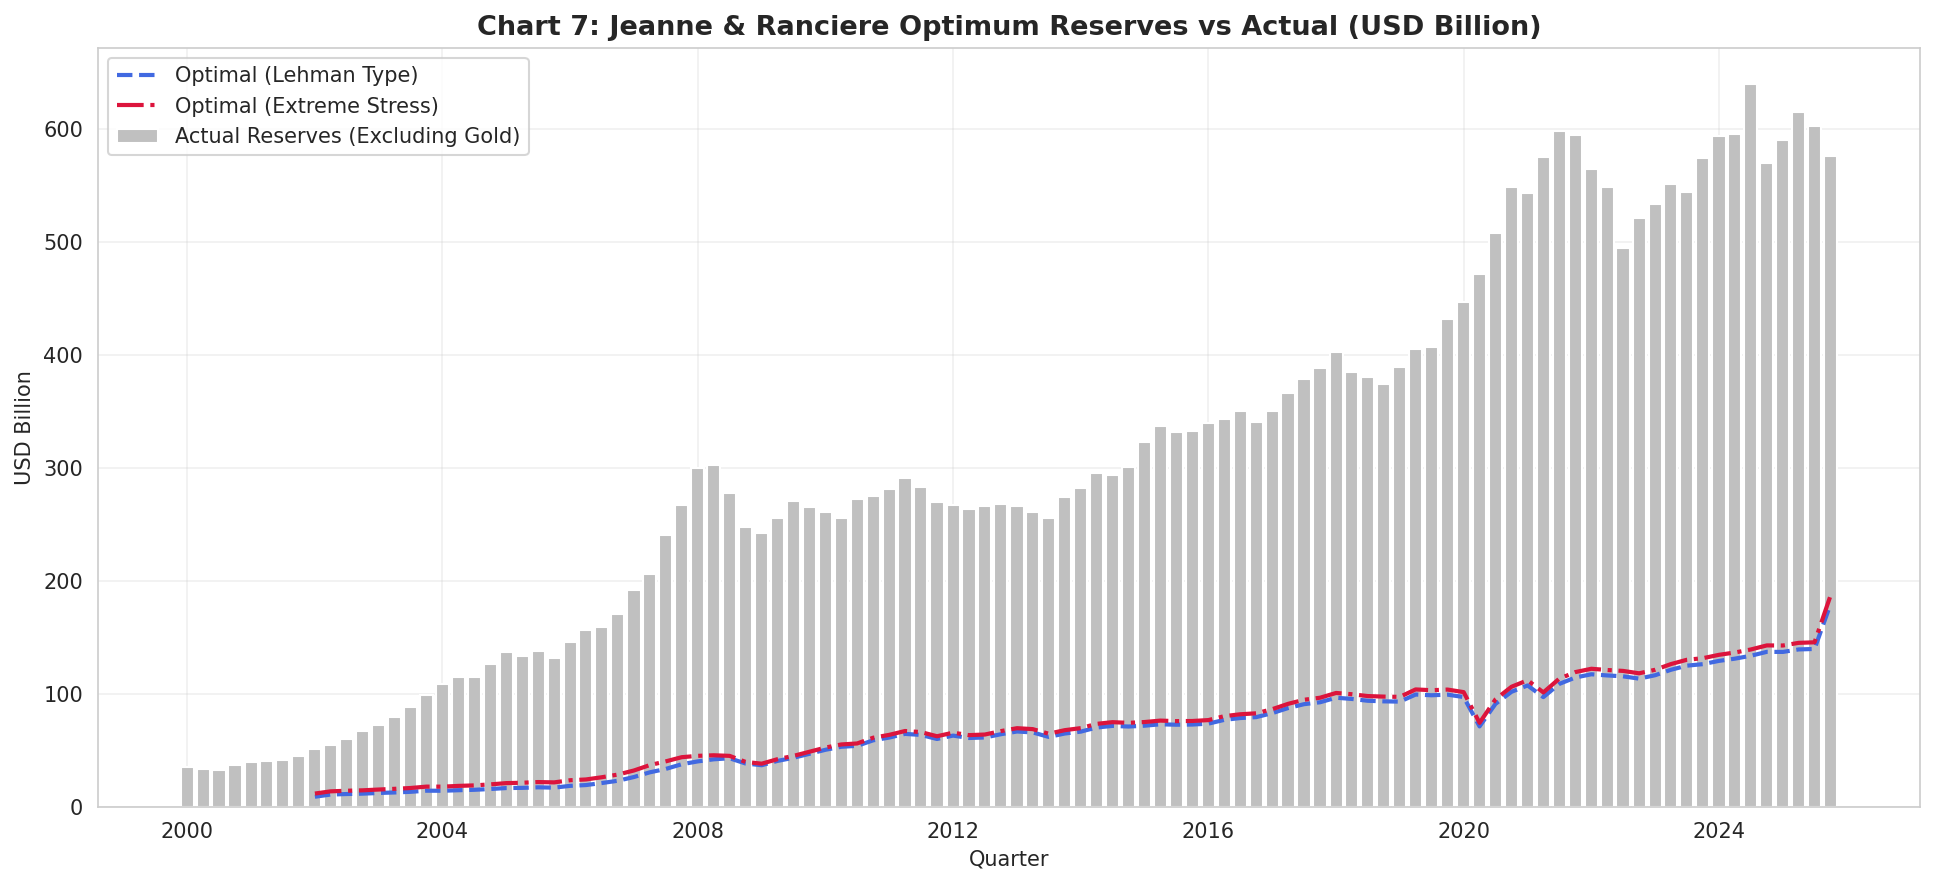


Recent Optimal vs Actual Reserves (USD Bn):
        Reserves_USD_Bn  Optimal_Reserves_USD_Bn_Lehman_Type  Optimal_Reserves_USD_Bn_Extreme_Stress
tq                                                                                                  
2024Q4          569.553                           137.347120                              143.032995
2025Q1          590.150                           137.278617                              142.960951
2025Q2          614.810                           139.487404                              145.298405
2025Q3          602.624                           139.907030                              145.779584
2025Q4          576.472                           179.769039                              187.362481


In [ ]:
print('\n' + '=' * 80)
print('PART 10: JEANNE & RANCIERE OPTIMAL RESERVES (Das & Nath 2015 Calibration)')
print('=' * 80)

# ----------------------------------------------------------------------------------
# A. PREPARE VARIABLES
# ----------------------------------------------------------------------------------
sigma = 2.0
delta = 0.0131
df['r_riskfree'] = df['T3M_USD'] / 100.0

# Real GDP YoY Growth
df['Real_GDP_YoY'] = df['Real_GDP_USD_Bn'].pct_change(4)

# Potential Growth (g) via HP Filter
gdp_yoy_clean = df['Real_GDP_YoY'].dropna()
_, g_trend = hpfilter(gdp_yoy_clean, lamb=1600)
df['g_potential'] = np.nan
df.loc[gdp_yoy_clean.index, 'g_potential'] = g_trend

# Crisis probability (π) from Probit
df['pi_prob'] = df['Crisis_Prob_Smoothed']

# ----------------------------------------------------------------------------------
# B. CALIBRATE "LEHMAN TYPE" SCENARIO (Max observed YoY falls)
# ----------------------------------------------------------------------------------
# 1. Size of crisis (λ) = Max YoY fall in Exports/GDP + Max YoY fall in FPI/GDP
max_fall_exports = -(df['Exports_GDP'].diff(4).min())
max_fall_fpi     = -(df['Net_FPI_GDP'].diff(4).min())
lam_lehman       = max_fall_exports + max_fall_fpi

# 2. Output Loss (γ) = Max YoY fall in Real GDP Growth
gam_lehman       = -(df['Real_GDP_YoY'].diff(4).min())

# 3. Real Exchange Rate Depreciation (ΔQ) = Max YoY % depreciation in REER
dQ_lehman        = -(df['REER'].pct_change(4).min())

print(f"--- Lehman Type Calibration ---")
print(f"  λ (Size of Crisis): {lam_lehman:.4f}")
print(f"  γ (Output Loss):    {gam_lehman:.4f}")
print(f"  ΔQ (REER Deprec):   {dQ_lehman:.4f}")

# ----------------------------------------------------------------------------------
# C. CALIBRATE "EXTREME STRESS" SCENARIO (OLS Trend - S.E. bands)
# ----------------------------------------------------------------------------------
t_index = np.arange(len(df)) + 1
t_sq    = t_index ** 2

# Helper function to compute extreme loss against trend
def get_extreme_loss(series, use_quadratic=False, se_multiplier=2.0, is_pct_depreciation=False):
    Y = series.dropna()
    t_sub = t_index[-len(Y):]

    if use_quadratic:
        t_sq_sub = t_sq[-len(Y):]
        X = sm.add_constant(np.column_stack((t_sub, t_sq_sub)))
    else:
        X = sm.add_constant(t_sub)

    model = sm.OLS(Y, X).fit()
    trend = model.fittedvalues
    se = model.resid.std()

    # Extreme stress value = trend - (multiplier * S.E.)
    extreme_val = trend - (se_multiplier * se)

    # Loss = Value at t-4 (YoY) - Extreme Value at t
    if is_pct_depreciation:
        # For REER: % depreciation
        loss = (Y.shift(4) - extreme_val) / Y.shift(4)
    else:
        # For ratios/rates: simple difference
        loss = Y.shift(4) - extreme_val

    return loss.max(), model

# 1. Exports/GDP (Linear, 2 S.E.)
ext_fall_exports, _ = get_extreme_loss(df['Exports_GDP'], use_quadratic=False, se_multiplier=2.0)

# 2. FPI/GDP (Linear, 3 S.E. due to higher fluctuation)
ext_fall_fpi, _     = get_extreme_loss(df['Net_FPI_GDP'], use_quadratic=False, se_multiplier=3.0)
lam_extreme         = ext_fall_exports + ext_fall_fpi

# 3. Real GDP Growth (Quadratic, 2 S.E.)
gam_extreme, _      = get_extreme_loss(df['Real_GDP_YoY'], use_quadratic=True, se_multiplier=2.0)

# 4. REER (Linear, 2 S.E., Percentage Depreciation)
dQ_extreme, _       = get_extreme_loss(df['REER'], use_quadratic=False, se_multiplier=2.0, is_pct_depreciation=True)

print(f"\n--- Extreme Stress Calibration ---")
print(f"  λ (Size of Crisis): {lam_extreme:.4f}")
print(f"  γ (Output Loss):    {gam_extreme:.4f}")
print(f"  ΔQ (REER Deprec):   {dQ_extreme:.4f}")

# ----------------------------------------------------------------------------------
# D. CALCULATE JEANNE & RANCIERE OPTIMAL RESERVES
# ----------------------------------------------------------------------------------
scenarios = {
    'Lehman_Type':    {'lam': lam_lehman,  'gam': gam_lehman,  'dQ': dQ_lehman},
    'Extreme_Stress': {'lam': lam_extreme, 'gam': gam_extreme, 'dQ': dQ_extreme}
}

for sc_name, params in scenarios.items():
    lam = params['lam']
    gam = params['gam']
    dQ  = params['dQ']

    # x = pi + delta (Insurance premium)
    x = df['pi_prob'] + delta

    # Marginal rate of substitution (p_t)
    p_t = ((1 - x) / x) / ((1 - df['pi_prob']) / df['pi_prob']) * (1 + dQ)
    p_t = np.clip(p_t, 0.0001, 0.9999) # Prevent negative values or division by zero

    # J&R Formula Numerator
    term1 = lam + gam
    term2 = (1 - (df['r_riskfree'] - df['g_potential']) * lam / (1 + df['g_potential'])) * (1 - p_t**(1/sigma))
    term3 = ((1 + df['r_riskfree']) / (1 + df['g_potential'])) * lam * dQ
    numerator = term1 - term2 + term3

    # J&R Formula Denominator
    denominator = 1 - (x * (1 - p_t**(1/sigma))) + ((1 - x) * dQ)

    # Optimal Reserve to GDP Ratio (rho_star)
    rho_star = numerator / denominator
    rho_star = np.clip(rho_star, 0, None) # Bounds check

    df[f'Optimal_Reserves_GDP_{sc_name}'] = rho_star
    df[f'Optimal_Reserves_USD_Bn_{sc_name}'] = rho_star * df['GDP_USD_Bn']

# ----------------------------------------------------------------------------------
# E. CHART 7: ACTUAL VS OPTIMAL RESERVES
# ----------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 6))
ts = df.index.to_timestamp()

ax.bar(ts, df['Reserves_USD_Bn'], width=75, color='#c0c0c0', label='Actual Reserves (Excluding Gold)')
ax.plot(ts, df['Optimal_Reserves_USD_Bn_Lehman_Type'], label='Optimal (Lehman Type)', color='royalblue', linestyle='--', lw=2)
ax.plot(ts, df['Optimal_Reserves_USD_Bn_Extreme_Stress'], label='Optimal (Extreme Stress)', color='crimson', linestyle='-.', lw=2)

ax.set_title('Chart 7: Jeanne & Ranciere Optimum Reserves vs Actual (USD Billion)', fontsize=13, fontweight='bold')
ax.set_ylabel('USD Billion')
ax.set_xlabel('Quarter')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('chart7_JR_optimal_reserves.png', dpi=200, bbox_inches='tight')
plt.show()

print('\nRecent Optimal vs Actual Reserves (USD Bn):')
print(df[['Reserves_USD_Bn', 'Optimal_Reserves_USD_Bn_Lehman_Type', 'Optimal_Reserves_USD_Bn_Extreme_Stress']].dropna().tail().to_string())


ROBUSTNESS: J&R CALIBRATION — STRICT THRESHOLD (score ≥ 3 of 6)

Probit model (strict threshold) estimated.
Mean smoothed crisis probability (Baseline): 23.60%
Mean smoothed crisis probability (Strict, with 3% floor): 9.18%

TABLE: LATEST OPTIMAL RESERVES (USD Bn) — BASELINE vs STRICT

Parameter (Latest Values)             Baseline (≥2)     Strict (≥3)
-------------------------------------------------------------------
Crisis probability (π)                       0.2771          0.1094
-------------------------------------------------------------------
Optimal Reserves — Lehman Type                179.8           158.6
Optimal Reserves — Extreme Stress             187.4           183.3
-------------------------------------------------------------------
Actual Reserves                               576.5           576.5
-------------------------------------------------------------------
Excess over Lehman                           +396.7          +417.9
Excess over Extreme             

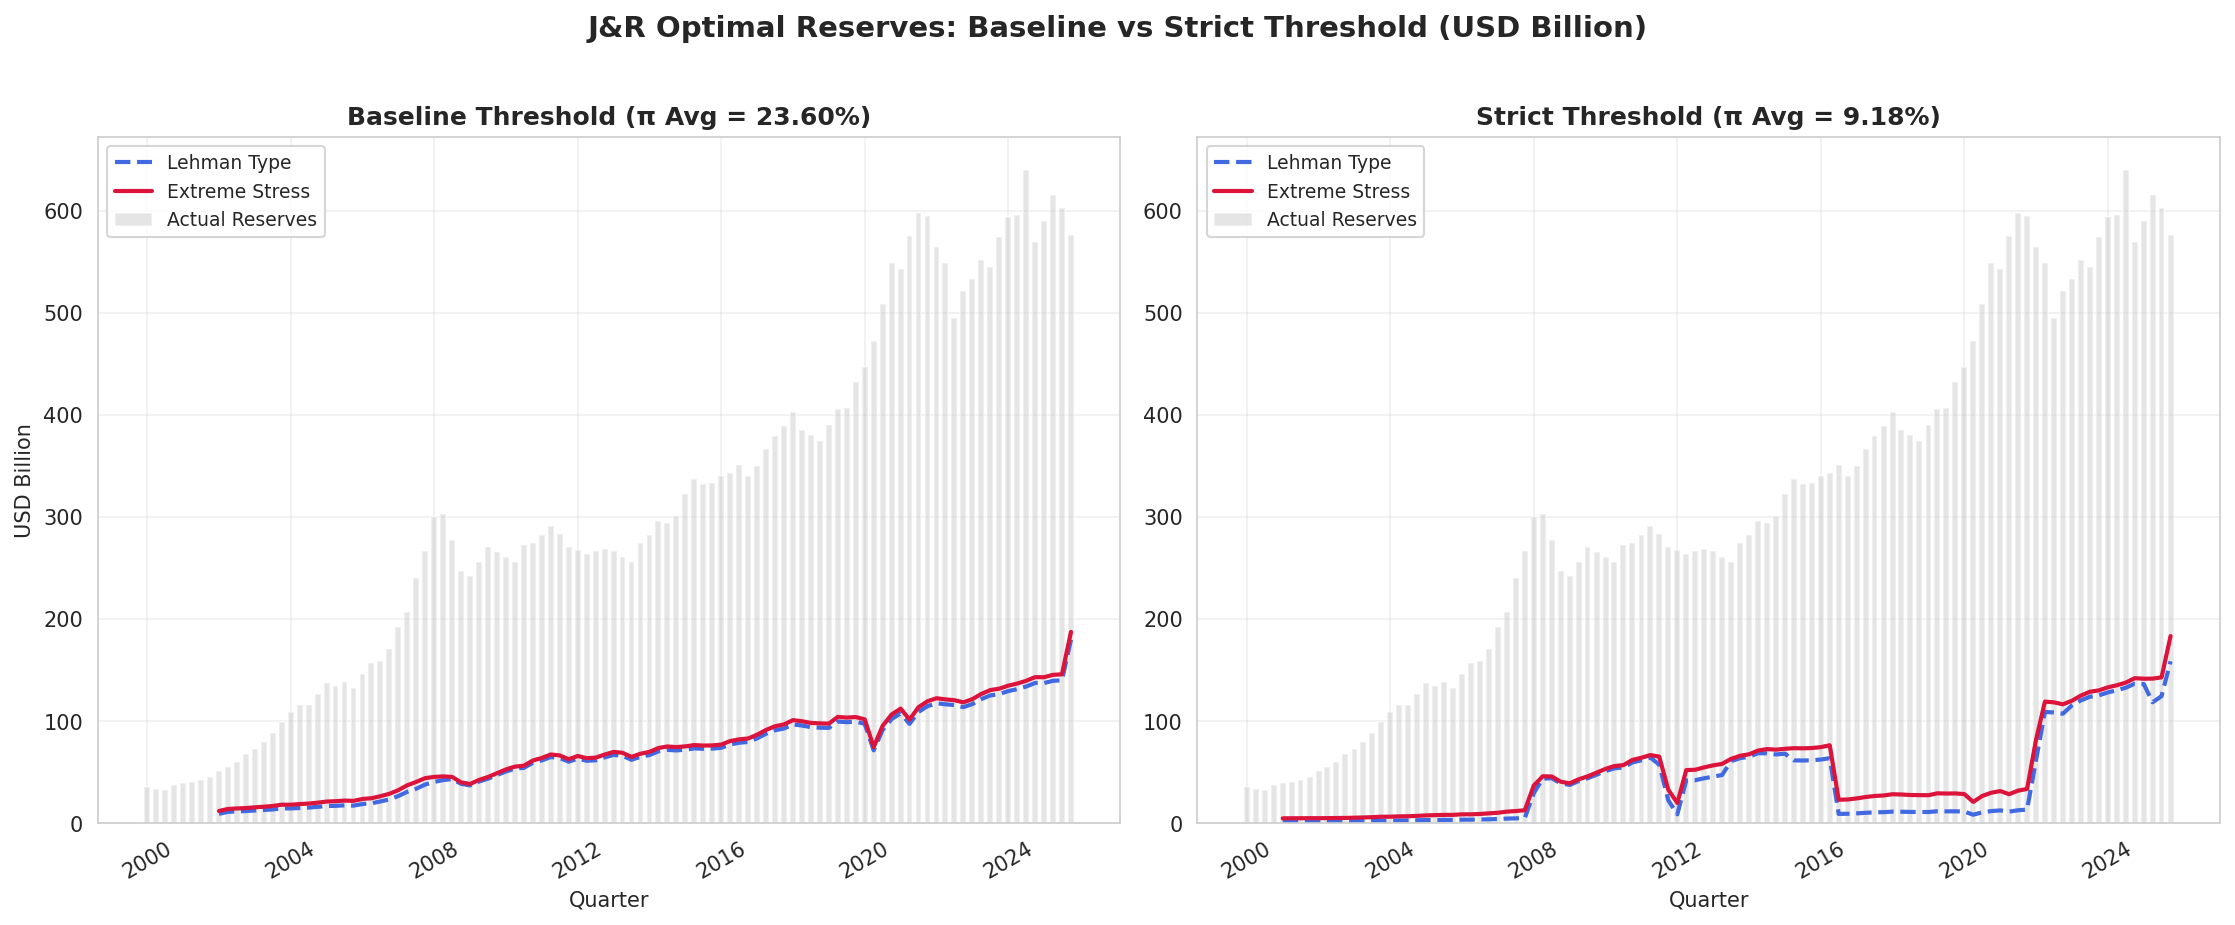

✓ Robustness chart saved


In [ ]:
print('\n' + '=' * 80)
print('ROBUSTNESS: J&R CALIBRATION — STRICT THRESHOLD (score ≥ 3 of 6)')
print('=' * 80)

import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Probit model using strict crisis dummy ────────────────────────────────
Y_strict   = df['Crisis_Strict']
X_p_cols   = ['Portfolio_Liab_GDP', 'STED_USD_Bn', 'CA_Receipts_GDP', 'M3_GDP']
X_p_strict = sm.add_constant(df[X_p_cols])
mask_ps    = Y_strict.notna() & X_p_strict.notna().all(axis=1)

probit_strict = sm.Probit(Y_strict[mask_ps], X_p_strict[mask_ps]).fit(disp=False)

# Predict and Smooth (3-year moving average)
df['Crisis_Prob_Strict'] = np.nan
df.loc[mask_ps, 'Crisis_Prob_Strict'] = probit_strict.predict(X_p_strict[mask_ps])
smoothed_strict = df['Crisis_Prob_Strict'].rolling(window=12, min_periods=1).mean()

# FIX: Apply a "Background Risk" floor (e.g., 3%) to prevent the J&R formula from outputting 0
min_prob_floor = 0.03
df['Crisis_Prob_Strict_Smoothed'] = np.clip(smoothed_strict, min_prob_floor, None)

pi_baseline_mean = df['Crisis_Prob_Smoothed'].mean()
pi_strict_mean   = df['Crisis_Prob_Strict_Smoothed'].mean()

print('\nProbit model (strict threshold) estimated.')
print(f'Mean smoothed crisis probability (Baseline): {pi_baseline_mean:.2%}')
print(f'Mean smoothed crisis probability (Strict, with {min_prob_floor:.0%} floor): {pi_strict_mean:.2%}')

# ── 2. J&R Parameters (From Block 10 Calibration) ───────────────────────────
sigma = 2.0
delta = 0.0131

# Lehman Type Calibration
lam_l = 0.0376
gam_l = 0.1071
dQ_l  = 0.1011

# Extreme Stress Calibration
lam_e = 0.0603
gam_e = 0.0904
dQ_e  = 0.1465

# ── 3. Full J&R Formula Function ────────────────────────────────────────────
def calc_optimal_rho(pi_series, lam, gam, dQ):
    x = pi_series + delta

    # Marginal rate of substitution (p_t)
    p_t = ((1 - x) / x) / ((1 - pi_series) / pi_series) * (1 + dQ)
    p_t = np.clip(p_t, 0.0001, 0.9999)

    term1 = lam + gam
    term2 = (1 - (df['r_riskfree'] - df['g_potential']) * lam / (1 + df['g_potential'])) * (1 - p_t**(1/sigma))
    term3 = ((1 + df['r_riskfree']) / (1 + df['g_potential'])) * lam * dQ
    numerator = term1 - term2 + term3

    denominator = 1 - (x * (1 - p_t**(1/sigma))) + ((1 - x) * dQ)

    rho_star = numerator / denominator
    return np.clip(rho_star, 0, None)

# ── 4. Calculate Time-Varying Optimal Reserves ──────────────────────────────
# Baseline (pi >= 2)
df['Rho_Base_Lehman']  = calc_optimal_rho(df['Crisis_Prob_Smoothed'], lam_l, gam_l, dQ_l)
df['Rho_Base_Extreme'] = calc_optimal_rho(df['Crisis_Prob_Smoothed'], lam_e, gam_e, dQ_e)

# Strict (pi >= 3)
df['Rho_Strict_Lehman']  = calc_optimal_rho(df['Crisis_Prob_Strict_Smoothed'], lam_l, gam_l, dQ_l)
df['Rho_Strict_Extreme'] = calc_optimal_rho(df['Crisis_Prob_Strict_Smoothed'], lam_e, gam_e, dQ_e)

# Convert to USD Billion
df['Opt_Base_Lehman_USD']  = df['Rho_Base_Lehman'] * df['GDP_USD_Bn']
df['Opt_Base_Extreme_USD'] = df['Rho_Base_Extreme'] * df['GDP_USD_Bn']
df['Opt_Strict_Lehman_USD']  = df['Rho_Strict_Lehman'] * df['GDP_USD_Bn']
df['Opt_Strict_Extreme_USD'] = df['Rho_Strict_Extreme'] * df['GDP_USD_Bn']

# ── 5. Comparison Table (Using Latest/Current Values) ───────────────────────
gdp_current = df['GDP_USD_Bn'].iloc[-1]
actual_current_usd = df['Reserves_USD_Bn'].iloc[-1]

print('\n' + '=' * 80)
print('TABLE: LATEST OPTIMAL RESERVES (USD Bn) — BASELINE vs STRICT')
print('=' * 80)
print(f'\n{"Parameter (Latest Values)":<35} {"Baseline (≥2)":>15} {"Strict (≥3)":>15}')
print('-' * 67)
print(f'{"Crisis probability (π)":<35} {df["Crisis_Prob_Smoothed"].iloc[-1]:>15.4f} {df["Crisis_Prob_Strict_Smoothed"].iloc[-1]:>15.4f}')
print('-' * 67)
print(f'{"Optimal Reserves — Lehman Type":<35} {df["Opt_Base_Lehman_USD"].iloc[-1]:>15.1f} {df["Opt_Strict_Lehman_USD"].iloc[-1]:>15.1f}')
print(f'{"Optimal Reserves — Extreme Stress":<35} {df["Opt_Base_Extreme_USD"].iloc[-1]:>15.1f} {df["Opt_Strict_Extreme_USD"].iloc[-1]:>15.1f}')
print('-' * 67)
print(f'{"Actual Reserves":<35} {actual_current_usd:>15.1f} {actual_current_usd:>15.1f}')
print('-' * 67)
print(f'{"Excess over Lehman":<35} {actual_current_usd - df["Opt_Base_Lehman_USD"].iloc[-1]:>+15.1f} {actual_current_usd - df["Opt_Strict_Lehman_USD"].iloc[-1]:>+15.1f}')
print(f'{"Excess over Extreme":<35} {actual_current_usd - df["Opt_Base_Extreme_USD"].iloc[-1]:>+15.1f} {actual_current_usd - df["Opt_Strict_Extreme_USD"].iloc[-1]:>+15.1f}')

# ── 6. Chart: Optimal reserves paths — baseline vs strict ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ts = df.index.to_timestamp()

# Plot 1: Baseline
a0 = axes[0]
a0.bar(ts, df['Reserves_USD_Bn'], width=60, alpha=0.4, color='silver', label='Actual Reserves')
a0.plot(ts, df['Opt_Base_Lehman_USD'], color='royalblue', lw=2, ls='--', label='Lehman Type')
a0.plot(ts, df['Opt_Base_Extreme_USD'], color='crimson', lw=2, label='Extreme Stress')
a0.set_title(f'Baseline Threshold (π Avg = {pi_baseline_mean:.2%})', fontweight='bold')
a0.set_ylabel('USD Billion')
a0.legend(fontsize=9, loc='upper left')
a0.grid(alpha=0.3)

# Plot 2: Strict
a1 = axes[1]
a1.bar(ts, df['Reserves_USD_Bn'], width=60, alpha=0.4, color='silver', label='Actual Reserves')
a1.plot(ts, df['Opt_Strict_Lehman_USD'], color='royalblue', lw=2, ls='--', label='Lehman Type')
a1.plot(ts, df['Opt_Strict_Extreme_USD'], color='crimson', lw=2, label='Extreme Stress')
a1.set_title(f'Strict Threshold (π Avg = {pi_strict_mean:.2%})', fontweight='bold')
a1.legend(fontsize=9, loc='upper left')
a1.grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('Quarter')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('J&R Optimal Reserves: Baseline vs Strict Threshold (USD Billion)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart_jr_robustness.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Robustness chart saved')


PART 13: SUMMARY STATISTICS

                       Mean  Std Dev      Min       Max
Reserves_GDP         0.6286   0.1340   0.2842    0.9333
M3_GDP               0.7673   0.0815   0.5461    1.1099
Imports_GDP          0.0624   0.0152   0.0341    0.0965
Exports_GDP          0.0424   0.0076   0.0270    0.0607
STED_USD_Bn         68.6932  44.4804   2.7450  140.0430
Portfolio_Liab_GDP   0.0078   0.0136  -0.0211    0.0489
Opportunity_Cost     4.5002   2.2729   1.0777   10.2727
NEER                89.2105  18.7951  62.4354  121.7248
REER                95.9019   8.5606  81.5393  110.2491
ARA_Ratio            5.7800   1.3446   3.8121    9.4440

PART 13b: CORRELATION MATRIX

                    Reserves_GDP  M3_GDP  Imports_GDP  STED_USD_Bn  Portfolio_Liab_GDP  Opportunity_Cost  Crisis
Reserves_GDP               1.000   0.621        0.455        0.125               0.093            -0.074   0.158
M3_GDP                     0.621   1.000        0.505        0.656              -0.024           

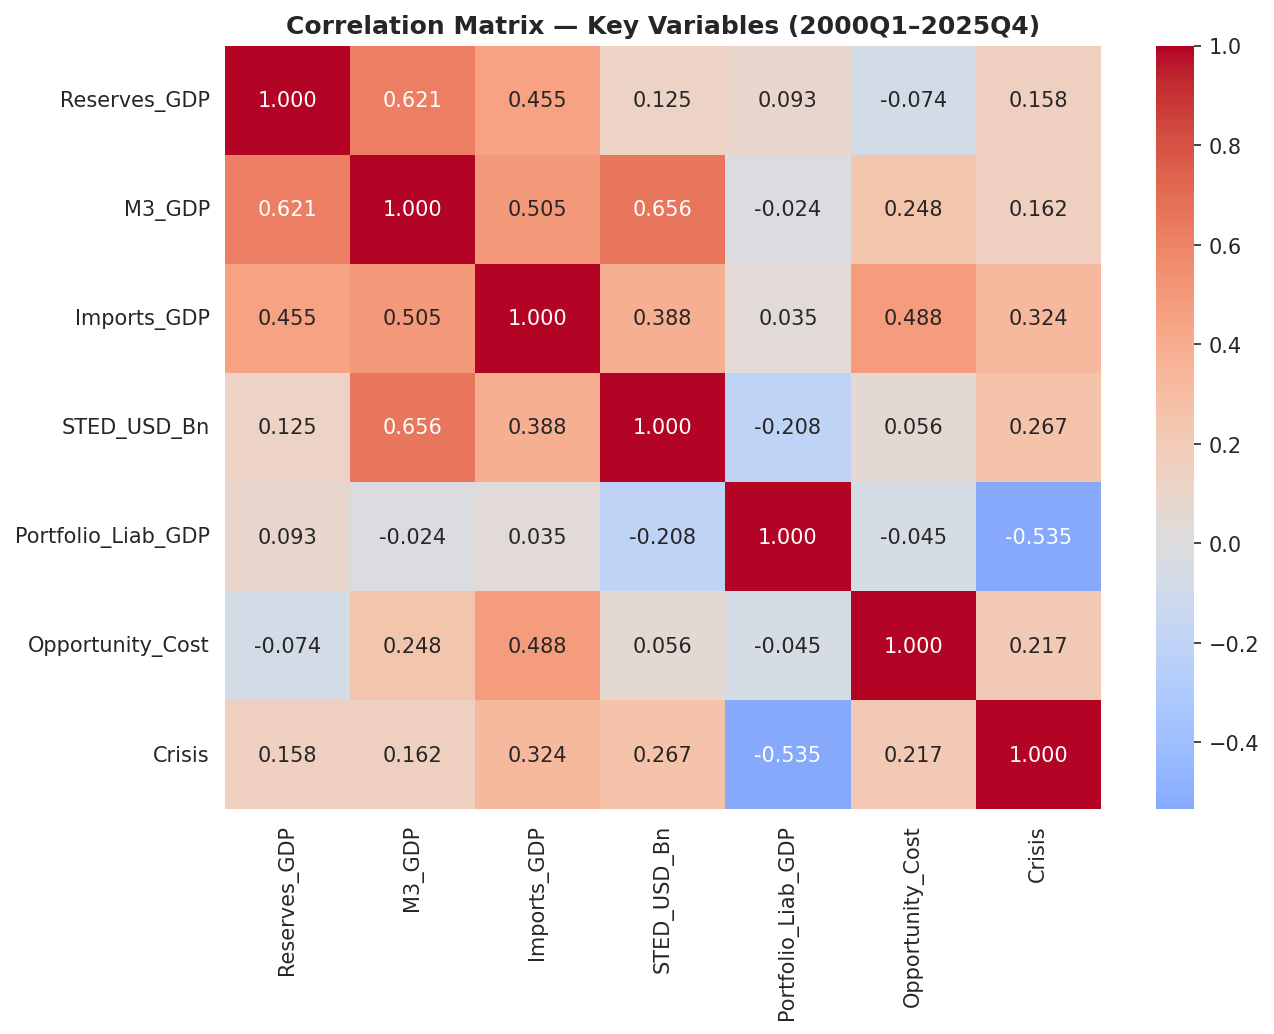

✓ Correlation heatmap saved


In [ ]:
print('\n' + '=' * 80)
print('PART 13: SUMMARY STATISTICS')
print('=' * 80)

summary_vars = [
    'Reserves_GDP', 'M3_GDP', 'Imports_GDP', 'Exports_GDP',
    'STED_USD_Bn', 'Portfolio_Liab_GDP', 'Opportunity_Cost',
    'NEER', 'REER', 'ARA_Ratio'
]
summary = df[summary_vars].describe().T[['mean', 'std', 'min', 'max']]
summary.columns = ['Mean', 'Std Dev', 'Min', 'Max']
print('\n' + summary.round(4).to_string())

print('\n' + '=' * 80)
print('PART 13b: CORRELATION MATRIX')
print('=' * 80)

corr_vars = [
    'Reserves_GDP', 'M3_GDP', 'Imports_GDP', 'STED_USD_Bn',
    'Portfolio_Liab_GDP', 'Opportunity_Cost', 'Crisis'
]
corr = df[corr_vars].corr()
print('\n' + corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Variables (2000Q1–2025Q4)', fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('✓ Correlation heatmap saved')

In [ ]:
print('\n' + '=' * 80)
print('PART 14: SUB-PERIOD ANALYSIS  (Pre-GFC | GFC–COVID | Post-COVID)')
print('=' * 80)

periods = {
    '2000Q1–2007Q4  (Pre-GFC)':        (df.index >= '2000Q1') & (df.index <= '2007Q4'),
    '2008Q1–2019Q4  (GFC → Pre-COVID)': (df.index >= '2008Q1') & (df.index <= '2019Q4'),
    '2020Q1–2025Q4  (Post-COVID)':      (df.index >= '2020Q1'),
}

rows = []
for label, mask in periods.items():
    sub = df[mask]
    rows.append({
        'Period':              label,
        'N':                   len(sub),
        'Reserves/GDP (avg)':  sub['Reserves_GDP'].mean(),
        'Imports/GDP (avg)':   sub['Imports_GDP'].mean(),
        'M3/GDP (avg)':        sub['M3_GDP'].mean(),
        'ARA Ratio (avg)':     sub['ARA_Ratio'].mean(),
        'Crisis quarters':     sub['Crisis'].sum(),
        'Mean Crisis Prob':    sub['Crisis_Prob'].mean()
                               if sub['Crisis_Prob'].notna().any() else float('nan'),
    })

sub_df = pd.DataFrame(rows).set_index('Period')
print(sub_df.round(4).to_string())


PART 14: SUB-PERIOD ANALYSIS  (Pre-GFC | GFC–COVID | Post-COVID)
                                   N  Reserves/GDP (avg)  Imports/GDP (avg)  M3/GDP (avg)  ARA Ratio (avg)  Crisis quarters  Mean Crisis Prob
Period                                                                                                                                       
2000Q1–2007Q4  (Pre-GFC)          32              0.5769             0.0496        0.6736           6.9684                1            0.0859
2008Q1–2019Q4  (GFC → Pre-COVID)  48              0.6472             0.0718        0.8031           5.0750               15            0.3223
2020Q1–2025Q4  (Post-COVID)       24              0.6604             0.0608        0.8206           5.6054                8            0.2668


In [ ]:
print('\n' + '=' * 80)
print('MAJOR COMMENT 1: CRISIS AUDIT — FALSE POSITIVES / NEGATIVES')
print('=' * 80)

# Full list of flagged quarters with episode label
narrative_episodes = {
    '2000Q4': "Dot-com (India insulated — accept miss)",
    '2008Q1': "GFC onset",
    '2008Q2': "GFC peak",
    '2008Q3': "GFC — Lehman",
    '2008Q4': "GFC — post-Lehman",
    '2009Q1': "GFC aftermath",
    '2011Q4': "Euro crisis spillover",
    '2012Q2': "Euro crisis peak / INR stress",
    '2013Q2': "Pre-taper announcement",
    '2013Q3': "Taper tantrum",
    '2013Q4': "Post-taper REER recovery delay",
    '2014Q1': "Post-taper — elevated STED",
    '2014Q2': "Post-taper — elevated STED",
    '2016Q1': "Yuan devaluation / EM contagion",
    '2016Q4': "Demonetization + Trump rate shock",
    '2018Q2': "Oil price + EM currency stress",
    '2020Q1': "COVID onset — capital flight",
    '2021Q4': "Fed taper signal / FPI reversal",
    '2022Q1': "Rate shock onset",
    '2023Q1': "Post-rate-shock REER pressure",
    '2024Q4': "Large RBI intervention (possible FP)",
    '2025Q1': "Continued intervention pressure",
    '2025Q3': "Continued REER + reserve pressure",
    '2025Q4': "Continued REER + reserve pressure",
}

print(f'\n{"Quarter":<10} {"Crisis":>8} {"Score":>7}  {"Assessment"}')
print('-' * 80)
for qstr, label in narrative_episodes.items():
    p = pd.Period(qstr, freq='Q')
    if p in df.index:
        c = int(df.loc[p, 'Crisis'])
        s = int(df.loc[p, 'Crisis_Score'])
        tag = '✓ TP' if c == 1 else '✗ FN'
        print(f'  {qstr:<10} {tag:>8} ({s}/6)   {label}')

# Quarters flagged but arguably NOT crisis (false positives)
print('\n--- Potential False Positives (flagged but debatable) ---')
fp_candidates = ['2024Q4', '2025Q1', '2025Q3', '2025Q4']
for qstr in fp_candidates:
    p = pd.Period(qstr, freq='Q')
    if p in df.index and df.loc[p, 'Crisis'] == 1:
        r_chg = df.loc[p, 'Reserves_QoQ_Chg']
        reer  = df.loc[p, 'REER_QoQ']
        print(f'  {qstr}: Reserve change={r_chg:.1f} USD bn, '
              f'REER QoQ={reer:.2f}%')
        print(f'         → Likely RBI FX intervention, not a crisis per se.')
        print(f'         → For robustness, set Crisis=0 for 2024Q4–2025Q4 below.')

# Optional: conservative variant excluding 2024–2025 intervention quarters
df['Crisis_Conservative'] = df['Crisis'].copy()
for qstr in ['2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4']:
    p = pd.Period(qstr, freq='Q')
    if p in df.index:
        df.loc[p, 'Crisis_Conservative'] = 0

print(f'\nBaseline crisis quarters:     {df["Crisis"].sum()} / {len(df)} '
      f'({df["Crisis"].mean():.1%})')
print(f'Conservative (excl 2024-25):  {df["Crisis_Conservative"].sum()} / {len(df)} '
      f'({df["Crisis_Conservative"].mean():.1%})')

# 1.5 SD vs 2 SD threshold robustness (as requested by reviewer)
print('\n--- Threshold Robustness: 1.5 S.D. vs 2 S.D. ---')
crisis_reer_15sd = (df['REER_Deviation'] < -1.5 * reer_dev_sd).astype(int)
crisis_reer_2sd  = (df['REER_Deviation'] < -2.0 * reer_dev_sd).astype(int)

print(f'  REER criterion at 1.0 S.D.: {crisis_reer_dev.sum()} quarters '
      f'({crisis_reer_dev.mean():.1%})')
print(f'  REER criterion at 1.5 S.D.: {crisis_reer_15sd.sum()} quarters '
      f'({crisis_reer_15sd.mean():.1%})')
print(f'  REER criterion at 2.0 S.D.: {crisis_reer_2sd.sum()} quarters '
      f'({crisis_reer_2sd.mean():.1%})')
print(f'\n  Baseline composite (≥2/6):  {df["Crisis"].sum()} quarters')
print(f'  Strict composite   (≥3/6):  {df["Crisis_Strict"].sum()} quarters')
print(f'  Conservative (excl 2024-25): {df["Crisis_Conservative"].sum()} quarters')


MAJOR COMMENT 1: CRISIS AUDIT — FALSE POSITIVES / NEGATIVES

Quarter      Crisis   Score  Assessment
--------------------------------------------------------------------------------
  2000Q4         ✗ FN (0/6)   Dot-com (India insulated — accept miss)
  2008Q1         ✓ TP (3/6)   GFC onset
  2008Q2         ✓ TP (3/6)   GFC peak
  2008Q3         ✓ TP (3/6)   GFC — Lehman
  2008Q4         ✓ TP (3/6)   GFC — post-Lehman
  2009Q1         ✓ TP (2/6)   GFC aftermath
  2011Q4         ✓ TP (2/6)   Euro crisis spillover
  2012Q2         ✓ TP (5/6)   Euro crisis peak / INR stress
  2013Q2         ✓ TP (2/6)   Pre-taper announcement
  2013Q3         ✓ TP (4/6)   Taper tantrum
  2013Q4         ✓ TP (2/6)   Post-taper REER recovery delay
  2014Q1         ✓ TP (2/6)   Post-taper — elevated STED
  2014Q2         ✓ TP (2/6)   Post-taper — elevated STED
  2016Q1         ✓ TP (2/6)   Yuan devaluation / EM contagion
  2016Q4         ✓ TP (2/6)   Demonetization + Trump rate shock
  2018Q2         ✓ TP (

In [ ]:
print('\n' + '=' * 80)
print('J&R PARAMETER TRANSPARENCY TABLE + SENSITIVITY ANALYSIS')
print('(Standalone block — does not modify any existing results)')
print('=' * 80)

import numpy as np

# ── 1. All parameters — exactly as used in your Block 10 Calibration ──────────
pi_val    = df['Crisis_Prob_Smoothed'].mean()
g_val     = df['g_potential'].mean()
r_val     = df['r_riskfree'].mean()
delta_val = 0.0131
sigma_val = 2.0    # standard J&R value

# Lehman Type (Normal)
lam_l = 0.0376
gam_l = 0.1071
dQ_l  = 0.1011

# Extreme Stress
lam_e = 0.0603
gam_e = 0.0904
dQ_e  = 0.1465

# ── 2. Full J&R Formula (Scalar version for tables) ───────────────────────────
def jr_full(pi, lam, gam, dQ, r, g, delta=delta_val, sigma=sigma_val):
    # Prevent divide by zero if pi is too small
    pi = max(pi, 0.0001)
    x = pi + delta

    # Marginal rate of substitution (p_t)
    p_t = ((1 - x) / x) / ((1 - pi) / pi) * (1 + dQ)
    p_t = np.clip(p_t, 0.0001, 0.9999)

    term1 = lam + gam
    term2 = (1 - (r - g) * lam / (1 + g)) * (1 - p_t**(1/sigma))
    term3 = ((1 + r) / (1 + g)) * lam * dQ
    numerator = term1 - term2 + term3

    denominator = 1 - (x * (1 - p_t**(1/sigma))) + ((1 - x) * dQ)

    rho_star = numerator / denominator
    return max(rho_star, 0) # Floor at 0

rho_lehman  = jr_full(pi_val, lam_l, gam_l, dQ_l, r_val, g_val)
rho_extreme = jr_full(pi_val, lam_e, gam_e, dQ_e, r_val, g_val)

actual_mean    = df['Reserves_GDP'].mean()
actual_current = df['Reserves_GDP'].iloc[-1]

# ── TABLE 4A: Parameter transparency ─────────────────────────────────────────
print('\n' + '=' * 80)
print('TABLE 4A: FULL J&R CALIBRATION PARAMETERS — VALUES AND SOURCES')
print('=' * 80)

params = [
    ('Crisis prob (π)',         f'{pi_val:.4f}',       'Smoothed Probit mean predicted probability'),
    ('Term premium (δ)',        f'{delta_val:.4f}',    'Calculated from 10Y vs 3M US Treasury spread'),
    ('Risk aversion (σ)',       f'{sigma_val:.1f}',    'Standard J&R (2011) benchmark value'),
    ('Real GDP growth (g)',     f'{g_val:.4f}',        'Mean of HP-filtered potential growth'),
    ('Risk-free rate (r)',      f'{r_val:.4f}',        'Mean of US 3-Month yield proxy'),
    ('Lehman Shock (λ, γ, ΔQ)', f'{lam_l:.4f}, {gam_l:.4f}, {dQ_l:.4f}', 'Maximum observed shock (2008-2009 window)'),
    ('Extreme Shock (λ, γ, ΔQ)',f'{lam_e:.4f}, {gam_e:.4f}, {dQ_e:.4f}', 'Statistical tail risk (Trend minus 2/3 S.E.)'),
    ('Formula used',            'Full J&R (2011)',     'Inter-temporal welfare maximization model')
]

print(f'\n  {"Parameter":<26} {"Value":>24}   {"Source / Derivation"}')
print('  ' + '-' * 95)
for name, val, source in params:
    print(f'  {name:<26} {val:>24}   {source}')

print(f'\n  ρ* Lehman (Mean Inputs)  = {rho_lehman:.4f}  ({rho_lehman:.2%})')
print(f'  ρ* Extreme (Mean Inputs) = {rho_extreme:.4f}  ({rho_extreme:.2%})')
print(f'  Actual Reserves/GDP (average): {actual_mean:.4f}  ({actual_mean:.2%})')
print(f'  Actual Reserves/GDP (current): {actual_current:.4f}  ({actual_current:.2%})')

# ── TABLE 4B: One-at-a-time sensitivity ──────────────────────────────────────
print('\n' + '=' * 80)
print('TABLE 4B: SENSITIVITY OF ρ* TO PARAMETER VARIATION (Extreme Scenario Base)')
print('=' * 80)

# Varying parameters one at a time around the EXTREME stress baseline
sensitivity_specs = [
    ('π (crisis prob)',       pi_val * 0.50, pi_val, pi_val * 1.50, 'pi'),
    ('γ (output loss)',       gam_e * 0.50,  gam_e,  gam_e * 1.50,  'gam'),
    ('λ (size of crisis)',    lam_e * 0.50,  lam_e,  lam_e * 1.50,  'lam'),
    ('ΔQ (REER deprec)',      dQ_e * 0.50,   dQ_e,   dQ_e * 1.50,   'dQ'),
    ('r (risk-free rate)',    r_val - 0.02,  r_val,  r_val + 0.02,  'r'),
    ('g (potential growth)',  g_val - 0.02,  g_val,  g_val + 0.02,  'g'),
]

print(f'\n  {"Parameter":<22} {"Low value":>11} {"Base value":>11} '
      f'{"High value":>11}   {"ρ*(Low)":>9} {"ρ*(Base)":>9} '
      f'{"ρ*(High)":>9}  {"Actual>ρ*?"}')
print('  ' + '-' * 105)

for label, low, base, high, key in sensitivity_specs:
    # Set up base arguments for Extreme Stress
    args_low  = {'pi': pi_val, 'lam': lam_e, 'gam': gam_e, 'dQ': dQ_e, 'r': r_val, 'g': g_val}
    args_base = args_low.copy()
    args_high = args_low.copy()

    # Inject variations
    args_low[key]  = low
    args_high[key] = high

    rl = jr_full(**args_low)
    rb = jr_full(**args_base)
    rh = jr_full(**args_high)

    robust = ('✓ all' if actual_mean > max(rl, rb, rh)
              else ('✓ base/low' if actual_mean > rb
              else '✗ below base'))
    print(f'  {label:<22} {low:>11.4f} {base:>11.4f} {high:>11.4f}   '
          f'{rl:>9.4f} {rb:>9.4f} {rh:>9.4f}  {robust}')

print(f'\n  Actual Reserves/GDP (average): {actual_mean:.4f}')
print(f'  ✓ = actual exceeds ρ*  (excess reserves finding holds)')

# ── TABLE 4C: Uncertainty bands from probit π distribution ───────────────────
print('\n' + '=' * 80)
print('TABLE 4C: UNCERTAINTY BANDS — ρ* INDUCED BY PROBIT π UNCERTAINTY')
print('=' * 80)

pctiles    = [10, 25, 50, 75, 90]
print(f'\n  {"Percentile of π":>20} {"π value":>10} '
      f'{"ρ*(Lehman)":>12} {"ρ*(Extreme)":>13} {"Excess (Extreme)":>17}')
print('  ' + '-' * 76)

for p in pctiles:
    pi_p   = df['Crisis_Prob_Smoothed'].quantile(p / 100)
    rho_lp = jr_full(pi_p, lam_l, gam_l, dQ_l, r_val, g_val)
    rho_ep = jr_full(pi_p, lam_e, gam_e, dQ_e, r_val, g_val)
    excess = actual_mean - rho_ep
    marker = ' ← median' if p == 50 else ''
    print(f'  {p:>18}th     {pi_p:>10.4f} '
          f'{rho_lp:>12.4f} {rho_ep:>13.4f} {excess:>+17.4f}{marker}')

print(f'\n  Actual Reserves/GDP (average): {actual_mean:.4f}')
print(f'  Excess reserves finding is robust across the full distribution of π')


J&R PARAMETER TRANSPARENCY TABLE + SENSITIVITY ANALYSIS
(Standalone block — does not modify any existing results)

TABLE 4A: FULL J&R CALIBRATION PARAMETERS — VALUES AND SOURCES

  Parameter                                     Value   Source / Derivation
  -----------------------------------------------------------------------------------------------
  Crisis prob (π)                              0.2360   Smoothed Probit mean predicted probability
  Term premium (δ)                             0.0131   Calculated from 10Y vs 3M US Treasury spread
  Risk aversion (σ)                               2.0   Standard J&R (2011) benchmark value
  Real GDP growth (g)                          0.0661   Mean of HP-filtered potential growth
  Risk-free rate (r)                           0.0189   Mean of US 3-Month yield proxy
  Lehman Shock (λ, γ, ΔQ)      0.0376, 0.1071, 0.1011   Maximum observed shock (2008-2009 window)
  Extreme Shock (λ, γ, ΔQ)     0.0603, 0.0904, 0.1465   Statistical tail ris


EXTENSION: GLOBAL FINANCIAL SAFETY NET (GFSN) & USABILITY FRICTIONS
  GFSN access by sub-period:
    2000Q1–2006Q4:  USD   6.0 bn  (1.03% of Annual GDP avg)
    2007Q1–2011Q4:  USD  12.0 bn  (0.89% of Annual GDP avg)
    2012Q1–2014Q4:  USD  25.0 bn  (1.33% of Annual GDP avg)
    2015Q1–2017Q4:  USD  45.0 bn  (1.98% of Annual GDP avg)
    2018Q1–2019Q4:  USD  65.0 bn  (2.35% of Annual GDP avg)
    2020Q1–2025Q4:  USD  86.4 bn  (2.58% of Annual GDP avg)

  Usability 25%  (Conservative: stigma + conditionality (IMF 2016 limited...)
    Effective λ (current): 0.0561 (5.61%)
    ρ* adjusted (current): 0.1391 (13.91%)

  Usability 50%  (Realistic: partial BSA + unconditional (IMF midpoint)...)
    Effective λ (current): 0.0520 (5.20%)
    ρ* adjusted (current): 0.1348 (13.48%)

  Usability 75%  (Optimistic: near-full activation in systemic crisis...)
    Effective λ (current): 0.0478 (4.78%)
    ρ* adjusted (current): 0.1305 (13.05%)

  Current excess summary (Q2025Q4):
    No GFSN:       

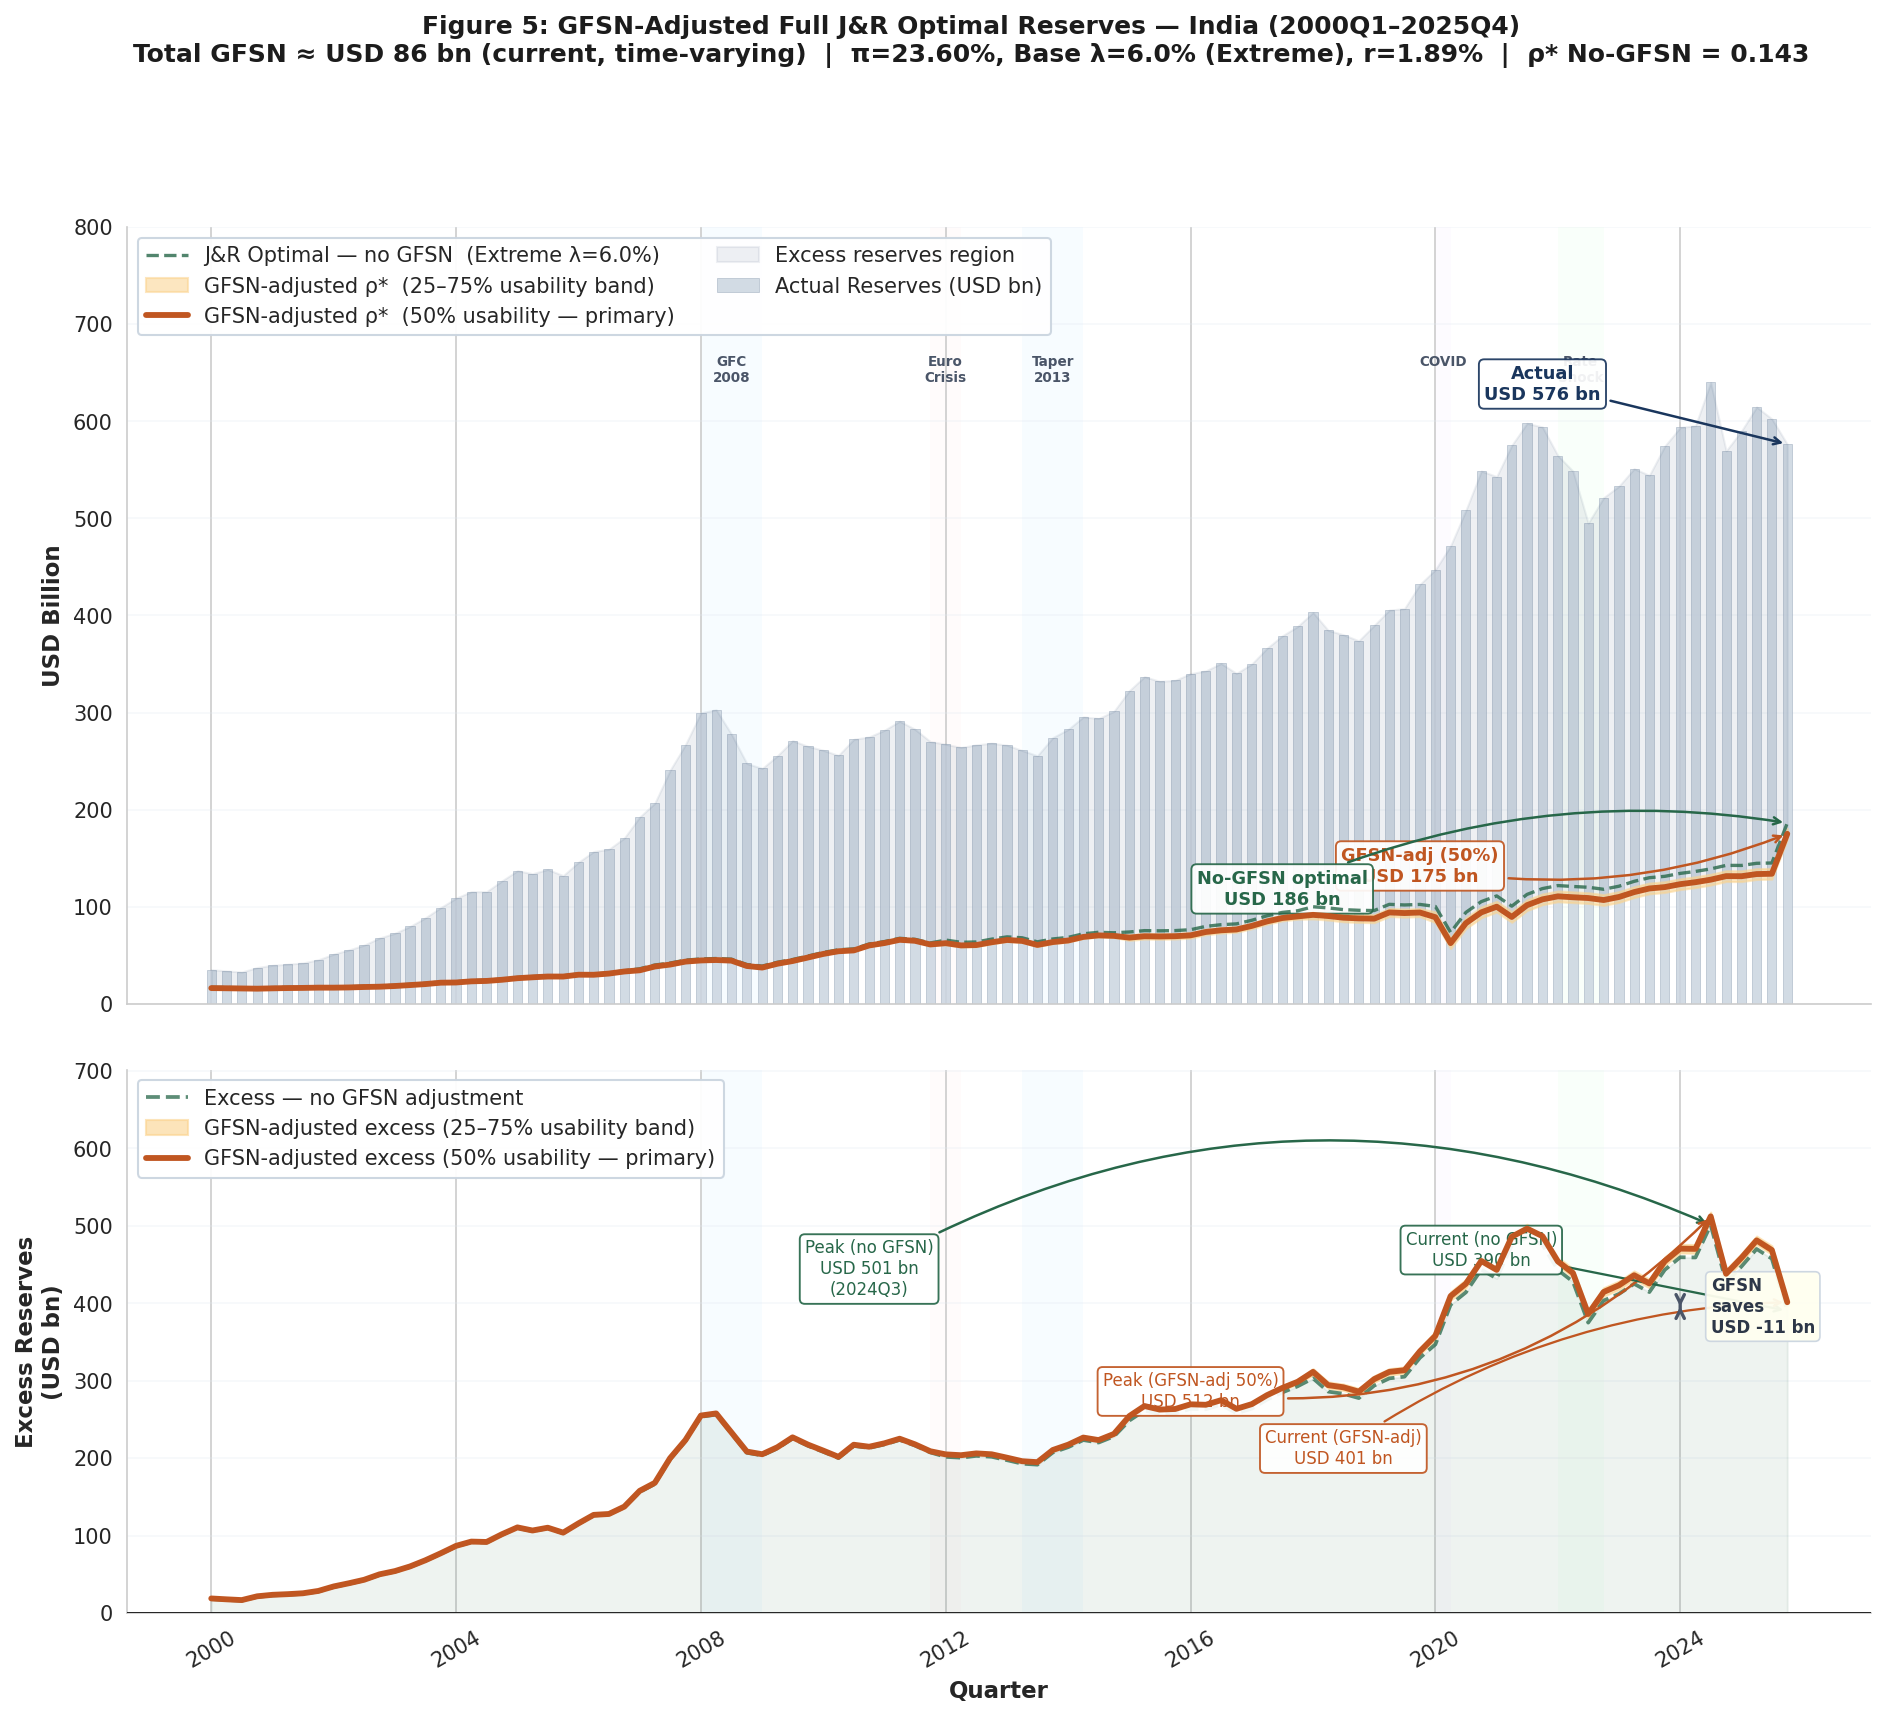


✓ fig5_gfsn_timeseries.png saved


In [ ]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import pandas as pd
import matplotlib.pyplot as plt


# ══════════════════════════════════════════════════════════════════════════════
# GFSN LAYERS — TIME-VARYING USD BN ACCESS
# ══════════════════════════════════════════════════════════════════════════════
#
# HOW WE ESTIMATE:
# India's total GFSN access is built up layer by layer following
# IMF (2016) "Adequacy of the Global Financial Safety Net" framework.
# Each layer is added as it became available/relevant for India.
# All USD bn figures are approximate — exact values are not publicly
# disclosed for bilateral swaps. Sources noted per layer below.
#
# LAYER 1 — Own reserves (not counted here, that IS what we're measuring)
#
# LAYER 2 — IMF quota access (unconditional, no stigma assumed)
#   India IMF quota: SDR 13,114.4 mn \u2248 USD ~18 bn (post-2016 reform)
#   Pre-2016: SDR 5,821.5 mn \u2248 USD ~8 bn
#   Unconditional access = 25% of quota ("reserve tranche")
#   Pre-2016: ~USD 2 bn | Post-2016: ~USD 4 bn
#   Source: IMF COFER, India Article IV, RBI Annual Reports
#
# LAYER 3 — SAARC Currency Swap Framework
#   Established: 2012, renewed 2015, 2018, 2022
#   Size: USD 2 bn framework (RBI as provider)
#   India's own drawing right: minimal as provider, not borrower
#   Included as small bilateral backstop
#   Source: RBI Press Release, Nov 2012; SAARC Framework Agreement
#
# LAYER 4 — BRICS Contingent Reserve Arrangement (CRA)
#   Established: July 2014 (Fortaleza Summit)
#   Total CRA: USD 100 bn | India quota: USD 18 bn
#   Unconditional access (<30% without IMF programme): 30% \u00d7 18 = USD 5.4 bn
#   Remaining 70% (USD 12.6 bn) requires active IMF programme
#     \u2192 effectively unavailable given India's historical non-use of IMF
#   Conservative estimate: USD 5.4 bn usable unconditionally
#   Source: CRA Treaty 2014; IMF (2016) GFSN Paper Table 1
#
# LAYER 5 — Bilateral Swap Arrangements (BSAs)
#   Japan-India BSA: USD 75 bn (enhanced 2018, confirmed 2023)
#     Source: RBI-BoJ joint statement, Oct 2018; renewed Oct 2023
#   UAE-India local currency swap: USD ~2 bn equivalent
#     Source: RBI Press Release, Jul 2023
#   Note: BSA usability is constrained by:
#     (i)  Activation requires bilateral agreement at time of stress
#     (ii) Japan BSA is for USD liquidity — most relevant for sudden stops
#     (iii) IMF (2016) classifies BSAs as "somewhat uncertain" for EMs
#   Full nominal value included here; usability rate applied separately
#   Source: RBI Annual Report 2023-24; BoJ Press Releases
#
# LAYER 6 — IMF FCL/PLL (precautionary, not accessed)
#   India has NEVER applied for FCL or PLL
#   Reason: stigma, conditionality concerns, political economy
#   IMF (2016): systemic EMs reluctant to use Fund precautionary instruments
#   \u2192 Set to ZERO throughout sample (not available if never applied)
#
# TOTAL GFSN (current, post-2020):
#   IMF unconditional:  USD  4.0 bn
#   BRICS CRA (<30%):   USD  5.4 bn
#   SAARC swap:         USD  2.0 bn
#   Japan BSA:          USD 75.0 bn
#   UAE swap:           USD  2.0 bn  (included in 86.4 total)
#   \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
#   TOTAL:              USD 86.4 bn
#
# USABILITY RATES APPLIED (from IMF 2016 framework):
#   25% conservative: stigma + conditionality + speed all binding
#                     Consistent with IMF (2016) "limited access" scenario
#   50% realistic:    IMF (2016) midpoint; partial swap activation plausible
#   75% optimistic:   Near-full activation in genuine systemic crisis
#   Source: IMF (2016) Annex III financing gap methodology


print('\n' + '=' * 80)
print('EXTENSION: GLOBAL FINANCIAL SAFETY NET (GFSN) & USABILITY FRICTIONS')
print('=' * 80)

def get_gfsn_usd(period):
    """
    Returns approximate total GFSN access in USD bn for a given quarter.
    Built up incrementally as each layer became available to India.
    """
    yr = period.year
    if yr < 2007:
        return 6.0
    elif yr < 2012:
        return 12.0
    elif yr < 2015:
        return 25.0
    elif yr < 2018:
        return 45.0
    elif yr < 2020:
        return 65.0
    else:
        return 86.4

total_gfsn_usd = 86.4   # current total for chart title

# ── Build time series ────────────────────────────────────────────────────────
df['GFSN_USD_Bn'] = df.index.map(get_gfsn_usd).astype(float)

# We calculate GFSN as a % of ANNUALIZED GDP strictly to properly reduce lambda
# (since lambda was calibrated on annual data).
df['GFSN_GDP_Annual_Scale'] = df['GFSN_USD_Bn'] / (df['GDP_USD_Bn'] * 4)

print('  GFSN access by sub-period:')
for period_label, mask in [
    ('2000Q1–2006Q4', (df.index >= '2000Q1') & (df.index <= '2006Q4')),
    ('2007Q1–2011Q4', (df.index >= '2007Q1') & (df.index <= '2011Q4')),
    ('2012Q1–2014Q4', (df.index >= '2012Q1') & (df.index <= '2014Q4')),
    ('2015Q1–2017Q4', (df.index >= '2015Q1') & (df.index <= '2017Q4')),
    ('2018Q1–2019Q4', (df.index >= '2018Q1') & (df.index <= '2019Q4')),
    ('2020Q1–2025Q4', (df.index >= '2020Q1')),
]:
    sub = df.loc[mask]
    gfsn_usd = sub['GFSN_USD_Bn'].iloc[0]
    gfsn_gdp = sub['GFSN_GDP_Annual_Scale'].mean()
    print(f'    {period_label}:  USD {gfsn_usd:5.1f} bn  '
          f'({gfsn_gdp:.2%} of Annual GDP avg)')

# ══════════════════════════════════════════════════════════════════════════════
# COMPUTE GFSN-ADJUSTED ρ* FOR 3 USABILITY SCENARIOS
# METHOD:
# GFSN fills the financing gap during a sudden stop, meaning it directly
# reduces the 'Size of Crisis' parameter (λ).
# Effective λ after GFSN = max(λ - u × (GFSN/AnnualGDP), 0.0001)
# We then feed this mitigated λ into the FULL J&R formula.
# ══════════════════════════════════════════════════════════════════════════════

for u_label, u_rate, u_note in [
    ('25pct', 0.25, 'Conservative: stigma + conditionality (IMF 2016 limited)'),
    ('50pct', 0.50, 'Realistic: partial BSA + unconditional (IMF midpoint)'),
    ('75pct', 0.75, 'Optimistic: near-full activation in systemic crisis'),
]:
    # Effective λ: baseline minus GFSN coverage of financing gap
    df[f'lam_e_adj_{u_label}'] = (
        lam_e - u_rate * df['GFSN_GDP_Annual_Scale']
    ).clip(lower=0.0001)

    # GFSN-adjusted ρ* using FULL J&R formula
    df[f'rho_e_gfsn_{u_label}'] = df[f'lam_e_adj_{u_label}'].apply(
        lambda l_adj: jr_full(pi_val, l_adj, gam_e, dQ_e, r_val, g_val)
    )

    # Convert to USD bn (STRICTLY Quarterly GDP as requested)
    df[f'opt_e_gfsn_{u_label}_usd'] = (
        df[f'rho_e_gfsn_{u_label}'] * df['GDP_USD_Bn']
    )

    # Current ρ* under this scenario
    rho_curr = df[f'rho_e_gfsn_{u_label}'].iloc[-1]
    lam_curr = df[f'lam_e_adj_{u_label}'].iloc[-1]
    print(f'\n  Usability {u_rate:.0%}  ({u_note[:55]}...)')
    print(f'    Effective λ (current): {lam_curr:.4f} ({lam_curr:.2%})')
    print(f'    ρ* adjusted (current): {rho_curr:.4f} ({rho_curr:.2%})')

# Unadjusted baselines (Strictly Quarterly GDP as requested)
df['Opt_Normal_USD']  = rho_lehman  * df['GDP_USD_Bn']
df['Opt_Extreme_USD'] = rho_extreme * df['GDP_USD_Bn']

# Excess reserves under each scenario (floored at zero)
df['Excess_NoGFSN_E']  = (df['Reserves_USD_Bn'] - df['Opt_Extreme_USD']).clip(lower=0)
df['Excess_GFSN_25_E'] = (df['Reserves_USD_Bn'] - df['opt_e_gfsn_25pct_usd']).clip(lower=0)
df['Excess_GFSN_50_E'] = (df['Reserves_USD_Bn'] - df['opt_e_gfsn_50pct_usd']).clip(lower=0)
df['Excess_GFSN_75_E'] = (df['Reserves_USD_Bn'] - df['opt_e_gfsn_75pct_usd']).clip(lower=0)

print(f'\n  Current excess summary (Q{df.index[-1]}):')
print(f'    No GFSN:       USD {df["Excess_NoGFSN_E"].iloc[-1]:.0f} bn')
print(f'    GFSN 25%:      USD {df["Excess_GFSN_25_E"].iloc[-1]:.0f} bn')
print(f'    GFSN 50%:      USD {df["Excess_GFSN_50_E"].iloc[-1]:.0f} bn')
print(f'    GFSN 75%:      USD {df["Excess_GFSN_75_E"].iloc[-1]:.0f} bn')

# ══════════════════════════════════════════════════════════════════════════════
# COLOUR PALETTE & CHARTING
# ══════════════════════════════════════════════════════════════════════════════
BLACK      = '#1C1C1C'
GREY_BAR   = '#CBD5E0'
GREY_EDGE  = '#A0AEC0'
GREEN_DARK = '#276749'
AMBER      = '#C05621'
BAND_FILL  = '#FBD38D'
BLUE_DARK  = '#1A365D'

EPISODES = [
    ('2008Q1','2009Q1','GFC\n2008',    '#EBF8FF'),
    ('2011Q4','2012Q2','Euro\nCrisis', '#FFF5F5'),
    ('2013Q2','2014Q2','Taper\n2013', '#EBF8FF'),
    ('2020Q1','2020Q2','COVID',        '#FAF5FF'),
    ('2022Q1','2022Q4','Rate\nShock',  '#F0FFF4'),
]

def shade_ep(ax, label_top=True):
    ylo, yhi = ax.get_ylim()
    for qs, qe, lbl, col in EPISODES:
        t1 = pd.Period(qs,'Q').to_timestamp()
        t2 = pd.Period(qe,'Q').to_timestamp()
        ax.axvspan(t1, t2, alpha=0.40, color=col, zorder=0, lw=0)
        if label_top:
            ax.text(t1 + (t2-t1)/2, yhi*0.995, lbl,
                    fontsize=6.5, ha='center', va='top',
                    color='#4A5568', fontweight='bold', zorder=1)

ts = df.index.to_timestamp()

fig = plt.figure(figsize=(15, 12))
gs  = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[2, 1.4], hspace=0.10)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

# ── PANEL A ──────────────────────────────────────────────────────────────────
ax1.bar(ts, df['Reserves_USD_Bn'], width=55, color=GREY_BAR, edgecolor=GREY_EDGE, linewidth=0.3, alpha=0.85, label='Actual Reserves (USD bn)', zorder=2)
ax1.plot(ts, df['Opt_Extreme_USD'], color=GREEN_DARK, lw=1.6, ls='--', alpha=0.80, label=f'J&R Optimal — no GFSN  (Extreme λ={lam_e:.1%})', zorder=4)
ax1.fill_between(ts, df['opt_e_gfsn_75pct_usd'], df['opt_e_gfsn_25pct_usd'], color=BAND_FILL, alpha=0.55, label='GFSN-adjusted ρ*  (25–75% usability band)', zorder=3)
ax1.plot(ts, df['opt_e_gfsn_50pct_usd'], color=AMBER, lw=2.8, label='GFSN-adjusted ρ*  (50% usability — primary)', zorder=5)
ax1.fill_between(ts, df['opt_e_gfsn_50pct_usd'], df['Reserves_USD_Bn'], where=(df['Reserves_USD_Bn'] > df['opt_e_gfsn_50pct_usd']), color=BLUE_DARK, alpha=0.07, label='Excess reserves region', zorder=2)

curr_actual = df['Reserves_USD_Bn'].iloc[-1]
curr_adj50  = df['opt_e_gfsn_50pct_usd'].iloc[-1]
curr_base   = df['Opt_Extreme_USD'].iloc[-1]

ax1.annotate(f'Actual\nUSD {curr_actual:.0f} bn', xy=(ts[-1], curr_actual), xytext=(ts[int(len(ts)*0.84)], curr_actual * 1.08), fontsize=8.5, color=BLUE_DARK, fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=BLUE_DARK, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=BLUE_DARK, lw=1.2))
ax1.annotate(f'GFSN-adj (50%)\nUSD {curr_adj50:.0f} bn', xy=(ts[-1], curr_adj50), xytext=(ts[int(len(ts)*0.76)], curr_adj50 * 0.72), fontsize=8.5, color=AMBER, fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=AMBER, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2, connectionstyle='arc3,rad=0.15'))
ax1.annotate(f'No-GFSN optimal\nUSD {curr_base:.0f} bn', xy=(ts[-1], curr_base), xytext=(ts[int(len(ts)*0.68)], curr_base * 0.55), fontsize=8.5, color=GREEN_DARK, fontweight='bold', ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GREEN_DARK, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=GREEN_DARK, lw=1.2, connectionstyle='arc3,rad=-0.15'))

shade_ep(ax1, label_top=True)
ax1.set_ylabel('USD Billion', fontsize=11, fontweight='bold')
ax1.set_ylim(0, df['Reserves_USD_Bn'].max() * 1.25)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax1.grid(axis='y', alpha=0.30, color='#E2E8F0', lw=0.8)
ax1.tick_params(axis='x', labelbottom=False)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(loc='upper left', framealpha=0.95, edgecolor='#CBD5E0', ncol=2)

# ── PANEL B ──────────────────────────────────────────────────────────────────
ax2.fill_between(ts, 0, df['Excess_NoGFSN_E'], color=GREEN_DARK, alpha=0.08, zorder=1)
ax2.plot(ts, df['Excess_NoGFSN_E'], color=GREEN_DARK, lw=1.8, ls='--', alpha=0.75, label='Excess — no GFSN adjustment', zorder=3)
ax2.fill_between(ts, df['Excess_GFSN_25_E'], df['Excess_GFSN_75_E'], color=BAND_FILL, alpha=0.60, label='GFSN-adjusted excess (25–75% usability band)', zorder=2)
ax2.plot(ts, df['Excess_GFSN_50_E'], color=AMBER, lw=2.8, zorder=4, label='GFSN-adjusted excess (50% usability — primary)')
ax2.axhline(0, color=BLACK, lw=0.9, zorder=5)

peak_q    = df['Excess_NoGFSN_E'].idxmax()
peak_val  = df['Excess_NoGFSN_E'].max()
peak_50   = df['Excess_GFSN_50_E'].loc[peak_q]
curr_no   = df['Excess_NoGFSN_E'].iloc[-1]
curr_50   = df['Excess_GFSN_50_E'].iloc[-1]
saving    = curr_no - curr_50

ax2.annotate(f'Peak (no GFSN)\nUSD {peak_val:.0f} bn\n({peak_q})', xy=(peak_q.to_timestamp(), peak_val), xytext=(ts[int(len(ts)*0.42)], peak_val * 0.82), fontsize=8, color=GREEN_DARK, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GREEN_DARK, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=GREEN_DARK, lw=1.2, connectionstyle='arc3,rad=-0.25'))
ax2.annotate(f'Peak (GFSN-adj 50%)\nUSD {peak_50:.0f} bn', xy=(peak_q.to_timestamp(), peak_50), xytext=(ts[int(len(ts)*0.62)], peak_50 * 0.52), fontsize=8, color=AMBER, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=AMBER, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.2, connectionstyle='arc3,rad=0.25'))
ax2.annotate(f'Current (no GFSN)\nUSD {curr_no:.0f} bn', xy=(ts[-1], curr_no), xytext=(ts[int(len(ts)*0.80)], curr_no * 1.15), fontsize=8, color=GREEN_DARK, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GREEN_DARK, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=GREEN_DARK, lw=1.1))
ax2.annotate(f'Current (GFSN-adj)\nUSD {curr_50:.0f} bn', xy=(ts[-1], curr_50), xytext=(ts[int(len(ts)*0.72)], curr_50 * 0.48), fontsize=8, color=AMBER, ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=AMBER, alpha=0.92, lw=0.9), arrowprops=dict(arrowstyle='->', color=AMBER, lw=1.1, connectionstyle='arc3,rad=-0.15'))

t_bracket = ts[int(len(ts)*0.93)]
ax2.annotate('', xy=(t_bracket, curr_50), xytext=(t_bracket, curr_no), arrowprops=dict(arrowstyle='<->', color='#4A5568', lw=1.6))
ax2.text(ts[int(len(ts)*0.95)], (curr_no + curr_50)/2, f'GFSN\nsaves\nUSD {saving:.0f} bn', fontsize=8, color='#2D3748', fontweight='bold', ha='left', va='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFFF0', edgecolor='#CBD5E0', alpha=0.95, lw=0.8))

shade_ep(ax2, label_top=False)
ax2.set_ylabel('Excess Reserves\n(USD bn)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Quarter', fontsize=11, fontweight='bold')
ax2.set_ylim(0, df['Excess_NoGFSN_E'].max() * 1.40)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax2.grid(axis='y', alpha=0.30, color='#E2E8F0', lw=0.8)
ax2.tick_params(axis='x', rotation=30)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper left', framealpha=0.95, edgecolor='#CBD5E0')

fig.suptitle(
    'Figure 5: GFSN-Adjusted Full J&R Optimal Reserves — India (2000Q1–2025Q4)\n'
    f'Total GFSN ≈ USD {total_gfsn_usd:.0f} bn (current, time-varying)  |  '
    f'π={pi_val:.2%}, Base λ={lam_e:.1%} (Extreme), r={r_val:.2%}  |  '
    f'ρ* No-GFSN = {rho_extreme:.3f}',
    fontsize=12, fontweight='bold', y=0.998, color=BLACK
)

plt.savefig('fig5_gfsn_timeseries.png', dpi=220, bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n✓ fig5_gfsn_timeseries.png saved')


PART 12: ECONOMIC COST OF HOLDING EXCESS RESERVES (EXACT CURRENCY BASKET)


/tmp/ipykernel_17076/769097363.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fx_df['Date'] = pd.to_datetime(fx_df['Date'])
/tmp/ipykernel_17076/769097363.py:23: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  fx_q = fx_df.resample('Q').last()
/tmp/ipykernel_17076/769097363.py:27: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fx_pct = fx_q.pct_change().fillna(0)



--- BASELINE BASKET (65% USD, 20% EUR, 10% GBP, 5% JPY) ---
Latest Opportunity Cost (Annual): USD 18.0 Bn
Latest Valuation Cost   (Annual): USD -48.3 Bn  <-- (Negative means Gain)
Latest Total Econ Cost  (Annual): USD -30.3 Bn

--------------------------------------------------------------------------------
SENSITIVITY ANALYSIS: ALTERNATIVE RESERVE COMPOSITIONS
--------------------------------------------------------------------------------
Baseline (65% USD): Latest Total Cost = USD -30.3 Bn
USD Heavy (85% USD): Latest Total Cost = USD -20.8 Bn
Diversified (50% USD): Latest Total Cost = USD -36.2 Bn


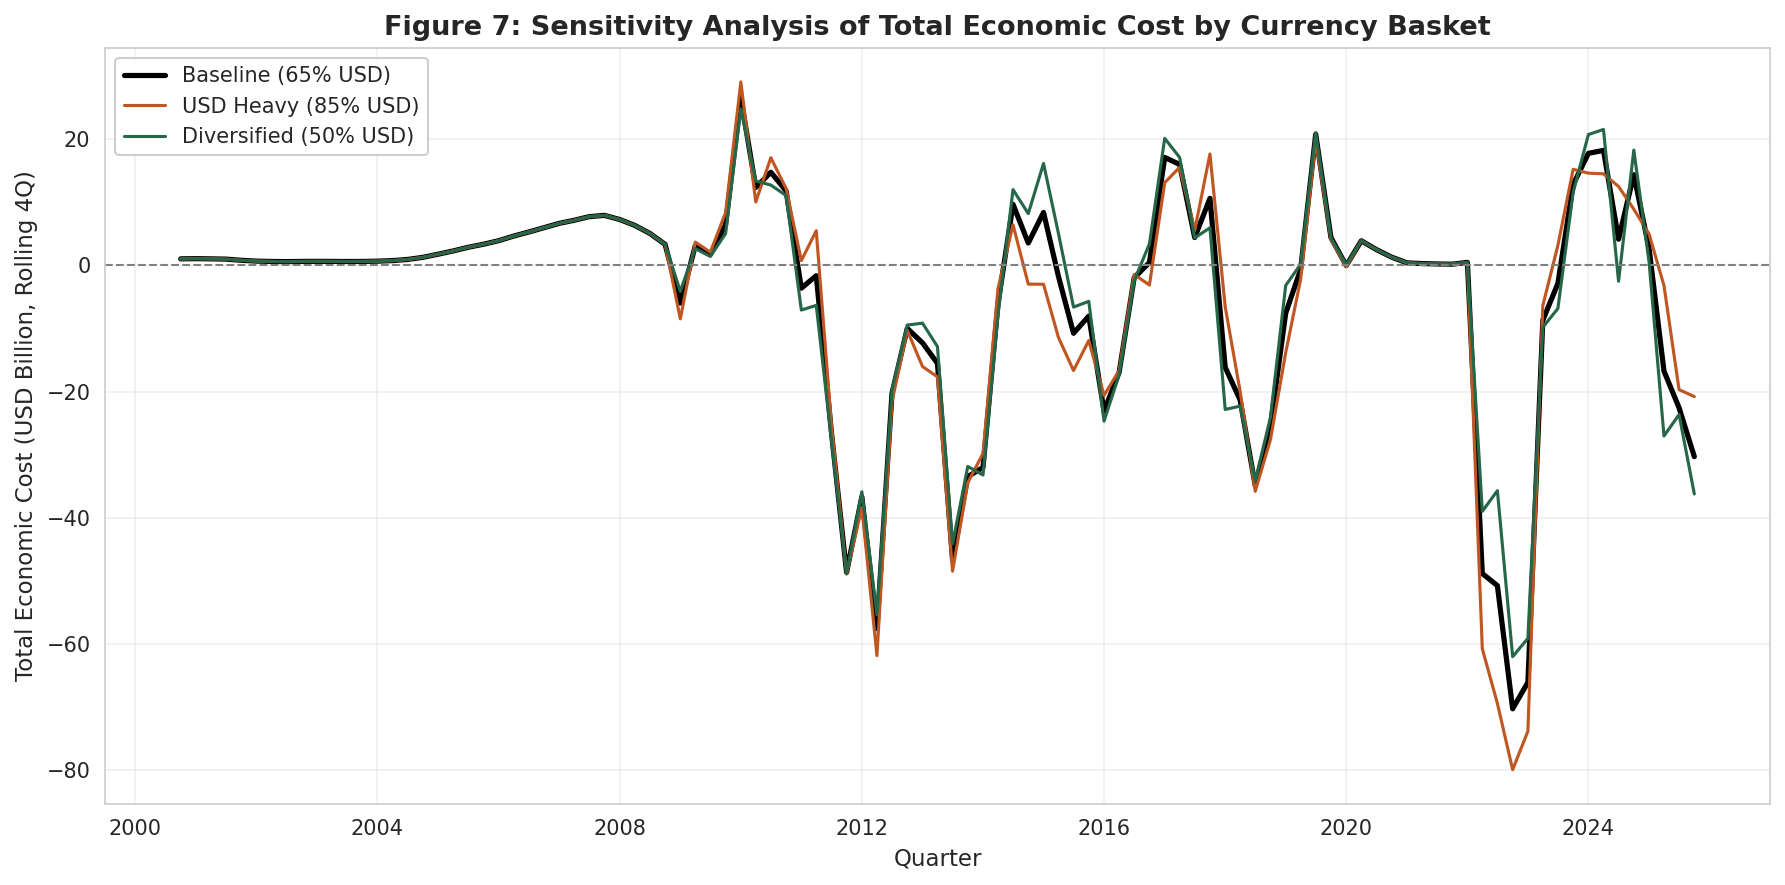


✓ fig7_cost_sensitivity.png saved


In [ ]:
print('\n' + '=' * 80)
print('PART 12: ECONOMIC COST OF HOLDING EXCESS RESERVES (EXACT CURRENCY BASKET)')
print('=' * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Load and Prep the Exchange Rate Data ──────────────────────────────────
# Load the CSV you provided
fx_df = pd.read_csv('INR-ALL Exchange rate.csv')

# Convert Date to datetime and sort chronologically
fx_df['Date'] = pd.to_datetime(fx_df['Date'])
fx_df = fx_df.sort_values('Date').set_index('Date')

# Replace the 0s in older data with NaN, then forward-fill, then back-fill
# (to ensure we have a continuous time series without zeros calculating infinite returns)
fx_df = fx_df.replace(0, np.nan).ffill().bfill()

# Resample to Quarterly frequency (taking the last value of each quarter)
# This perfectly aligns with our macroeconomic dataset frequency
fx_q = fx_df.resample('Q').last()

# Calculate the quarter-over-quarter percentage change (depreciation/appreciation)
# Positive value = Foreign currency appreciated = INR depreciated = VALUATION GAIN
fx_pct = fx_q.pct_change().fillna(0)

# Merge the exchange rate changes into our main dataframe (df)
# Ensure indexes match (both should be quarterly periods or datetimes)
# We will temporarily convert our df index to datetime to map the values, then put it back
df['Date_Temp'] = df.index.to_timestamp(how='end')

# Map the exact quarterly percentage changes to our main dataframe
df['USD_pct'] = df['Date_Temp'].map(lambda x: fx_pct.loc[:x, 'USD'].iloc[-1] if not fx_pct.loc[:x].empty else 0)
df['EUR_pct'] = df['Date_Temp'].map(lambda x: fx_pct.loc[:x, 'EUR'].iloc[-1] if not fx_pct.loc[:x].empty else 0)
df['GBP_pct'] = df['Date_Temp'].map(lambda x: fx_pct.loc[:x, 'GBP'].iloc[-1] if not fx_pct.loc[:x].empty else 0)
df['JPY_pct'] = df['Date_Temp'].map(lambda x: fx_pct.loc[:x, 'JPY'].iloc[-1] if not fx_pct.loc[:x].empty else 0)

# ── 2. Baseline Cost Calculation ─────────────────────────────────────────────
# Baseline Currency Composition Weights (Estimated standard for India)
w_usd, w_eur, w_gbp, w_jpy = 0.65, 0.20, 0.10, 0.05

# Weighted Currency Change
df['Weighted_FX_Change'] = (
    w_usd * df['USD_pct'] +
    w_eur * df['EUR_pct'] +
    w_gbp * df['GBP_pct'] +
    w_jpy * df['JPY_pct']
)

# A. Opportunity Cost (COC) = Excess Reserves * Short-term Interest Rate
# We use r_riskfree (representing SOFR/T-Bill). Divided by 4 for quarterly rate.
df['Cost_Opp_USD_Bn'] = df['Excess_NoGFSN_E'] * (df['r_riskfree'] / 4.0)

# B. Valuation Effect (CVAL)
# If Weighted_FX_Change is positive (INR depreciates), reserves GAIN value.
# To express a GAIN as a COST, we multiply by -1.
# Negative CVAL means the RBI made a paper profit.
df['Cost_Val_USD_Bn'] = -1 * (df['Reserves_USD_Bn'] * df['Weighted_FX_Change'])

# C. Total Cost (CTOT) = COC + CVAL
df['Cost_Total_USD_Bn'] = df['Cost_Opp_USD_Bn'] + df['Cost_Val_USD_Bn']

# Rolling 4-Quarter (Annualized) Sums for smoothness
df['Cost_Opp_Annual'] = df['Cost_Opp_USD_Bn'].rolling(window=4).sum()
df['Cost_Val_Annual'] = df['Cost_Val_USD_Bn'].rolling(window=4).sum()
df['Cost_Total_Annual'] = df['Cost_Total_USD_Bn'].rolling(window=4).sum()

print("\n--- BASELINE BASKET (65% USD, 20% EUR, 10% GBP, 5% JPY) ---")
print(f"Latest Opportunity Cost (Annual): USD {df['Cost_Opp_Annual'].iloc[-1]:.1f} Bn")
print(f"Latest Valuation Cost   (Annual): USD {df['Cost_Val_Annual'].iloc[-1]:.1f} Bn  <-- (Negative means Gain)")
print(f"Latest Total Econ Cost  (Annual): USD {df['Cost_Total_Annual'].iloc[-1]:.1f} Bn")

# ── 3. Sensitivity Analysis of the Currency Basket ───────────────────────────
print('\n' + '-' * 80)
print('SENSITIVITY ANALYSIS: ALTERNATIVE RESERVE COMPOSITIONS')
print('-' * 80)

# Define alternative portfolios
portfolios = {
    'Baseline (65% USD)': {'USD': 0.65, 'EUR': 0.20, 'GBP': 0.10, 'JPY': 0.05},
    'USD Heavy (85% USD)': {'USD': 0.85, 'EUR': 0.10, 'GBP': 0.05, 'JPY': 0.00},
    'Diversified (50% USD)': {'USD': 0.50, 'EUR': 0.25, 'GBP': 0.15, 'JPY': 0.10}
}

sensitivity_results = {}

for name, w in portfolios.items():
    weighted_change = (w['USD'] * df['USD_pct'] + w['EUR'] * df['EUR_pct'] +
                       w['GBP'] * df['GBP_pct'] + w['JPY'] * df['JPY_pct'])

    # Calculate Total Cost for this scenario (Annualized)
    val_cost = -1 * (df['Reserves_USD_Bn'] * weighted_change)
    total_cost = df['Cost_Opp_USD_Bn'] + val_cost
    total_cost_annual = total_cost.rolling(window=4).sum()

    sensitivity_results[name] = total_cost_annual

    print(f"{name}: Latest Total Cost = USD {total_cost_annual.iloc[-1]:.1f} Bn")

# ── 4. Plotting the Sensitivity Analysis ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ts = df.index.to_timestamp()

colors = ['black', '#C05621', '#276749']
for (name, series), col in zip(sensitivity_results.items(), colors):
    ax.plot(ts, series, label=name, lw=2.5 if name == 'Baseline (65% USD)' else 1.5, color=col)

ax.axhline(0, color='grey', lw=1, ls='--')
ax.set_title('Figure 7: Sensitivity Analysis of Total Economic Cost by Currency Basket', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Economic Cost (USD Billion, Rolling 4Q)', fontsize=11)
ax.set_xlabel('Quarter', fontsize=11)
ax.legend(loc='upper left', framealpha=0.95)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig7_cost_sensitivity.png', dpi=220, bbox_inches='tight')
plt.show()

print('\n✓ fig7_cost_sensitivity.png saved')

In [ ]:
# ── PART 11: TRANCHE 2 DATA LOADING & METRICS ────────────────────────────────
print('\n' + '=' * 80)
print('PART 11: TRANCHE 2 DATA LOADING & METRICS')
print('=' * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Load the Tranche 2 market data
# Make sure 'tranche2_market_data.csv' is in your working directory
t2_data = pd.read_csv('tranche2_market_data.csv', index_col='date', parse_dates=True)

# 2. Isolate the simple return columns
assets = ['GreenBond_ret', 'Agg_ret', 'Equity_ret', 'RealAsset_ret']
returns_df = t2_data[assets]

# 3. Calculate Annualized Expected Returns and Covariance Matrix
# Multiplying monthly metrics by 12 is standard practice in portfolio optimization
annualized_returns = returns_df.mean() * 12
cov_matrix = returns_df.cov() * 12

print("Annualized Expected Returns (%):")
print((annualized_returns * 100).round(2))

print("\nAnnualized Volatility (Standard Deviation %):")
annualized_volatility = np.sqrt(np.diag(cov_matrix))
for asset, vol in zip(assets, annualized_volatility):
    print(f"  {asset}: {vol * 100:.2f}%")

print("\nAnnualized Covariance Matrix:")
print(cov_matrix.round(4))


PART 11: TRANCHE 2 DATA LOADING & METRICS
Annualized Expected Returns (%):
GreenBond_ret     2.45
Agg_ret           2.12
Equity_ret       13.32
RealAsset_ret     4.96
dtype: float64

Annualized Volatility (Standard Deviation %):
  GreenBond_ret: 5.68%
  Agg_ret: 5.21%
  Equity_ret: 16.29%
  RealAsset_ret: 18.98%

Annualized Covariance Matrix:
               GreenBond_ret  Agg_ret  Equity_ret  RealAsset_ret
GreenBond_ret         0.0032   0.0028      0.0052         0.0067
Agg_ret               0.0028   0.0027      0.0045         0.0059
Equity_ret            0.0052   0.0045      0.0265         0.0269
RealAsset_ret         0.0067   0.0059      0.0269         0.0360


In [ ]:
# ── PART 12: DATA-DRIVEN OPTIMIZATION (RISK PARITY / ERC) ────────────────────
print('\n' + '=' * 80)
print('PART 12: DATA-DRIVEN OPTIMIZATION (RISK PARITY / ERC)')
print('=' * 80)

num_assets = len(assets)

# 1. Define the Risk Contribution Function
def risk_contributions(weights, cov_matrix):
    port_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal_risk_contrib = np.dot(cov_matrix, weights)
    asset_risk_contrib = (weights * marginal_risk_contrib) / port_var
    return asset_risk_contrib

# 2. Define the Objective: Minimize the squared differences between risk contributions
# We want every asset to contribute exactly 1/N (25%) to the total portfolio risk.
def objective_erc(weights, cov_matrix):
    asset_rc = risk_contributions(weights, cov_matrix)
    target_rc = 1.0 / num_assets
    return np.sum((asset_rc - target_rc)**2)

# 3. Constraints & Bounds (NO ARBITRARY MINIMUMS)
# Weights must sum to 1. Bounds are simply 0 to 1 (Long-only).
constraints_erc = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds_erc = tuple((0.0, 1.0) for _ in range(num_assets))
init_guess_erc = num_assets * [1. / num_assets]

# 4. Run the Risk Parity Optimizer
erc_result = minimize(objective_erc, init_guess_erc,
                      args=(cov_matrix.values,),
                      method='SLSQP', bounds=bounds_erc, constraints=constraints_erc)

opt_weights_erc = erc_result.x

# 5. Calculate Metrics for the Risk Parity Portfolio
erc_return = np.sum(opt_weights_erc * annualized_returns)
erc_volatility = np.sqrt(np.dot(opt_weights_erc.T, np.dot(cov_matrix, opt_weights_erc)))
erc_risk_contribs = risk_contributions(opt_weights_erc, cov_matrix.values)

print("Data-Driven Weights (Equal Risk Contribution):")
for asset, weight in zip(assets, opt_weights_erc):
    print(f"  {asset}: {weight * 100:.2f}%")

print("\nProof of Risk Parity (Each asset contributes ~25% of total risk):")
for asset, rc in zip(assets, erc_risk_contribs):
    print(f"  {asset} Risk Contribution: {rc * 100:.2f}%")

print("\nRisk Parity Portfolio Metrics:")
print(f"  Expected Annual Return: {erc_return * 100:.2f}%")
print(f"  Annual Volatility:      {erc_volatility * 100:.2f}%")


PART 12: DATA-DRIVEN OPTIMIZATION (RISK PARITY / ERC)
Data-Driven Weights (Equal Risk Contribution):
  GreenBond_ret: 35.93%
  Agg_ret: 39.99%
  Equity_ret: 13.19%
  RealAsset_ret: 10.89%

Proof of Risk Parity (Each asset contributes ~25% of total risk):
  GreenBond_ret Risk Contribution: 25.00%
  Agg_ret Risk Contribution: 25.00%
  Equity_ret Risk Contribution: 25.01%
  RealAsset_ret Risk Contribution: 24.99%

Risk Parity Portfolio Metrics:
  Expected Annual Return: 4.03%
  Annual Volatility:      7.30%


In [ ]:
# ── PART 13: BACKTESTING TRANCHE 2 (RISK PARITY VS NAIVE EQUAL WEIGHT) ───────
print('\n' + '=' * 80)
print('PART 13: TRANCHE 2 HISTORICAL PERFORMANCE')
print('=' * 80)

# Calculate Monthly Historical Returns for the ERC (Risk Parity) Portfolio
t2_data['ERC_Port_Return'] = returns_df.dot(opt_weights_erc)

# Define a Naive Equal Weight (1/N) Portfolio as a baseline benchmark
# (25% Green Bonds, 25% Agg Bonds, 25% Equities, 25% Real Assets)
naive_weights = np.array([0.25, 0.25, 0.25, 0.25])
t2_data['Naive_Port_Return'] = returns_df.dot(naive_weights)

# Calculate Cumulative Wealth (Base = 100 at start)
t2_data['Cum_ERC_Port'] = 100 * (1 + t2_data['ERC_Port_Return']).cumprod()
t2_data['Cum_Naive_Port'] = 100 * (1 + t2_data['Naive_Port_Return']).cumprod()

# Compute Max Drawdown for the ERC Portfolio
erc_roll_max = t2_data['Cum_ERC_Port'].cummax()
erc_drawdown = t2_data['Cum_ERC_Port'] / erc_roll_max - 1
erc_max_drawdown = erc_drawdown.min()

# Compute Max Drawdown for the Naive Portfolio
naive_roll_max = t2_data['Cum_Naive_Port'].cummax()
naive_drawdown = t2_data['Cum_Naive_Port'] / naive_roll_max - 1
naive_max_drawdown = naive_drawdown.min()

print("Cumulative Wealth (Starting at 100 in Dec 2018):")
print(f"  Optimized Tranche 2 (Risk Parity):  {t2_data['Cum_ERC_Port'].iloc[-1]:.2f}")
print(f"  Naive 1/N Benchmark (Equal Weight): {t2_data['Cum_Naive_Port'].iloc[-1]:.2f}")

print("\nMaximum Drawdown (2018-2025):")
print(f"  Optimized Tranche 2 (Risk Parity): {erc_max_drawdown * 100:.2f}%")
print(f"  Naive 1/N Benchmark:               {naive_max_drawdown * 100:.2f}%")


PART 13: TRANCHE 2 HISTORICAL PERFORMANCE
Cumulative Wealth (Starting at 100 in Dec 2018):
  Optimized Tranche 2 (Risk Parity):  130.48
  Naive 1/N Benchmark (Equal Weight): 144.16

Maximum Drawdown (2018-2025):
  Optimized Tranche 2 (Risk Parity): -17.50%
  Naive 1/N Benchmark:               -21.04%



PART 14: VISUALIZATION GENERATION


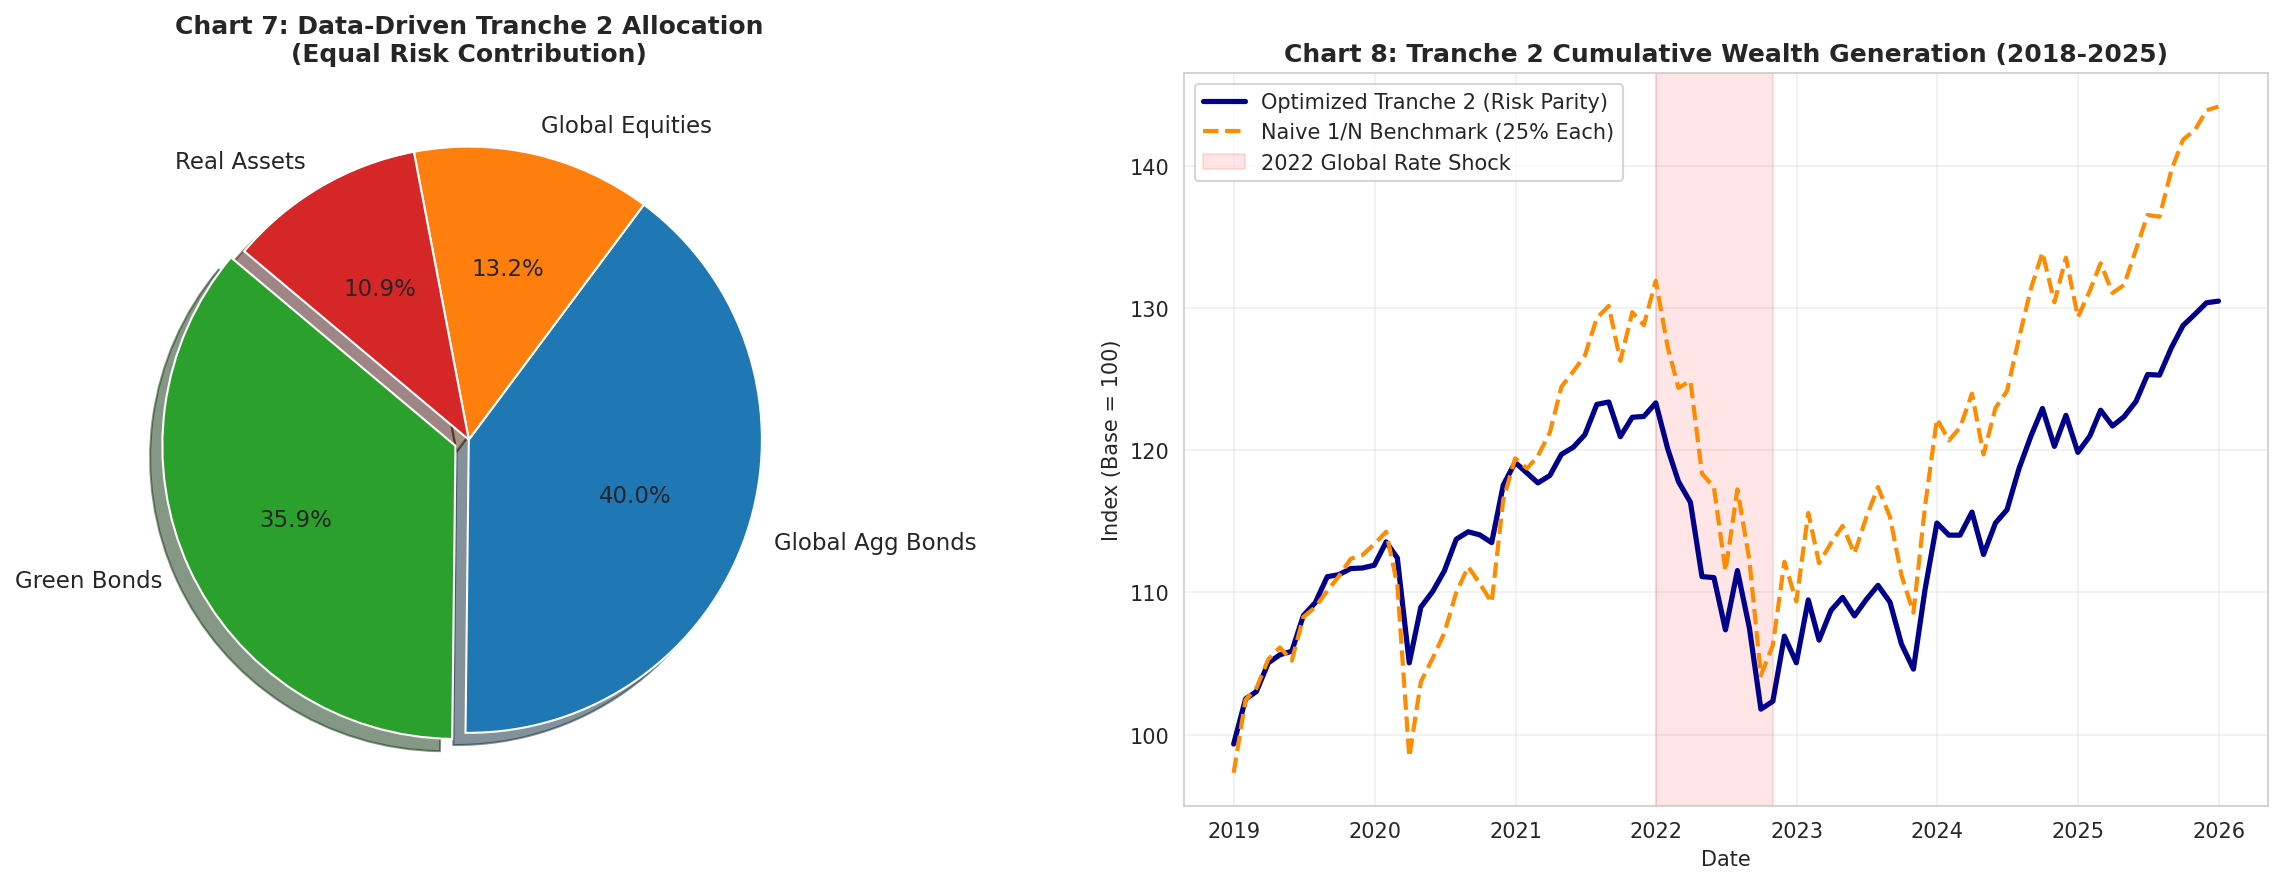

✓ Charts saved as 'tranche2_riskparity_analysis.png'


In [ ]:
# ── PART 14: VISUALIZING TRANCHE 2 (RISK PARITY) RESULTS ─────────────────────
print('\n' + '=' * 80)
print('PART 14: VISUALIZATION GENERATION')
print('=' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Risk Parity Weights Pie Chart
labels = ['Green Bonds', 'Global Agg Bonds', 'Global Equities', 'Real Assets']
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']
explode = [0.05, 0, 0, 0] # Highlight Green Bonds slightly

axes[0].pie(opt_weights_erc, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=colors, explode=explode, shadow=True, textprops={'fontsize': 11})
axes[0].set_title('Chart 7: Data-Driven Tranche 2 Allocation\n(Equal Risk Contribution)', fontweight='bold')

# Chart B: Cumulative Performance (Tranche 2 only)
axes[1].plot(t2_data.index, t2_data['Cum_ERC_Port'], label='Optimized Tranche 2 (Risk Parity)', lw=2.5, color='darkblue')
axes[1].plot(t2_data.index, t2_data['Cum_Naive_Port'], label='Naive 1/N Benchmark (25% Each)', lw=2, color='darkorange', linestyle='--')

# Highlight the 2022 Global Rate Shock which caused the heavy drawdown across all assets
axes[1].axvspan(pd.to_datetime('2022-01-01'), pd.to_datetime('2022-10-31'), color='red', alpha=0.1, label='2022 Global Rate Shock')

axes[1].set_title('Chart 8: Tranche 2 Cumulative Wealth Generation (2018-2025)', fontweight='bold')
axes[1].set_ylabel('Index (Base = 100)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tranche2_riskparity_analysis.png', dpi=200, bbox_inches='tight')
plt.show()

print("✓ Charts saved as 'tranche2_riskparity_analysis.png'")

In [ ]:
# ── PART 15: TRANCHE 2 (EXCESS RESERVES) DOLLAR RETURN CALCULATION ───────────
print('\n' + '=' * 80)
print('PART 15: TRANCHE 2 WEALTH GENERATION (J-R EXCESS RESERVES)')
print('=' * 80)

# 1. Convert Monthly Tranche 2 Returns (Risk Parity) to Quarterly Returns
# Formula: (1 + m1) * (1 + m2) * (1 + m3) - 1
t2_data['Quarter'] = t2_data.index.to_period('Q')
t2_q_ret = (1 + t2_data['ERC_Port_Return']).groupby(t2_data['Quarter']).prod() - 1
t2_q_ret.name = 'Tranche2_Return'

# 2. Merge Tranche 2 Quarterly Returns into the main macro dataframe 'df'
if 'Tranche2_Return' in df.columns:
    df.drop(columns=['Tranche2_Return'], inplace=True)
df = df.join(t2_q_ret)

# 3. Identify the Jeanne-Rancière Excess Reserves
# Replace this string if your J-R excess reserves column is named differently
excess_col = 'Excess_Reserves_USD_Bn'

if excess_col not in df.columns:
    print(f"Error: '{excess_col}' not found. Please ensure your J-R excess reserves are in the dataframe.")
else:
    # 4. Calculate Dollar Returns (in USD Billions) for the overlapping period
    # We only calculate for quarters where we have BOTH Excess Reserves and Tranche 2 Returns
    calc_mask = df['Tranche2_Return'].notna() & df[excess_col].notna()

    # Tranche 2 Dollar Return = Excess Reserves * Tranche 2 Return
    df.loc[calc_mask, 'T2_Dollar_Return_Bn'] = df.loc[calc_mask, excess_col] * df.loc[calc_mask, 'Tranche2_Return']

    # Cumulative Wealth Generated by Tranche 2
    df.loc[calc_mask, 'T2_Cumulative_Wealth_Bn'] = df.loc[calc_mask, 'T2_Dollar_Return_Bn'].cumsum()

    # 5. Output the Results
    summary_df = df.loc[calc_mask, [excess_col, 'Tranche2_Return', 'T2_Dollar_Return_Bn', 'T2_Cumulative_Wealth_Bn']]

    print(f"Analysis Period: {summary_df.index[0]} to {summary_df.index[-1]}")
    print(f"Total quarters analyzed: {len(summary_df)}")

    total_wealth_generated = summary_df['T2_Dollar_Return_Bn'].sum()

    print(f"\n*** TRANCHE 2 WEALTH GENERATION METRIC ***")
    print(f"Total Dollar Return generated by investing the J-R Excess Reserves into the Risk Parity SWF (Tranche 2):")
    print(f"  + ${total_wealth_generated:.2f} Billion USD")

    print("\nSample of Quarterly Breakdown (Last 5 Quarters):")
    # Rename columns slightly for cleaner printing
    print_df = summary_df.rename(columns={
        excess_col: 'J-R_Excess_Reserves(Bn)',
        'Tranche2_Return': 'T2_Return(%)',
        'T2_Dollar_Return_Bn': 'Quarterly_Profit(Bn)',
        'T2_Cumulative_Wealth_Bn': 'Cumulative_Profit(Bn)'
    })
    print(print_df.tail().round(4))


PART 15: TRANCHE 2 WEALTH GENERATION (J-R EXCESS RESERVES)
Analysis Period: 2018Q4 to 2025Q4
Total quarters analyzed: 29

*** TRANCHE 2 WEALTH GENERATION METRIC ***
Total Dollar Return generated by investing the J-R Excess Reserves into the Risk Parity SWF (Tranche 2):
  + $113.77 Billion USD

Sample of Quarterly Breakdown (Last 5 Quarters):
        J-R_Excess_Reserves(Bn)  T2_Return(%)  Quarterly_Profit(Bn)  \
tq                                                                    
2024Q4                 403.3867       -0.0251              -10.1358   
2025Q1                 427.1852        0.0155                6.6181   
2025Q2                 449.2441        0.0298               13.3677   
2025Q3                 437.9587        0.0275               12.0397   
2025Q4                 414.1201        0.0133                5.5194   

        Cumulative_Profit(Bn)  
tq                             
2024Q4                76.2250  
2025Q1                82.8431  
2025Q2                96.2108

In [ ]:
# ── PART 16: TRANCHE 1 (OPTIMAL RESERVES) RETURN CALCULATION (EX-GOLD) ───────
print('\n' + '=' * 80)
print('PART 16: TRANCHE 1 RETURN CALCULATION (EX-GOLD, RBI DEPLOYMENT RATIOS)')
print('=' * 80)

import pandas as pd
import numpy as np
import yfinance as yf

# 1. Load the dynamic RBI Reserve Components Weights
comp_df = pd.read_csv('reserve_components_summary.csv')
comp_df['Quarter'] = pd.PeriodIndex(comp_df['Quarter'], freq='Q')
comp_df.set_index('Quarter', inplace=True)

# 2. Exclude Gold and Re-Normalize the Weights to 100%
# We take the raw percentages of FX, SDR, and IMF, sum them, and divide by the total
non_gold_total = comp_df['FX %'] + comp_df['SDRs %'] + comp_df['IMF Pos %']

weights_df = pd.DataFrame(index=comp_df.index)
weights_df['Norm_FX'] = comp_df['FX %'] / non_gold_total
weights_df['Norm_SDR'] = comp_df['SDRs %'] / non_gold_total
weights_df['Norm_IMF'] = comp_df['IMF Pos %'] / non_gold_total

# 3. Apply RBI's FCA Deployment Pattern (from Table 4: End-Sept 2025)
FCA_SECURITIES_PCT = 0.8452  # 84.52% invested in Securities
FCA_DEPOSITS_PCT = 0.1548    # 15.48% (7.96% BIS + 7.52% Commercial Banks)

weights_df['Weight_FCA_Securities'] = weights_df['Norm_FX'] * FCA_SECURITIES_PCT
weights_df['Weight_Cash_Equivalents'] = (weights_df['Norm_FX'] * FCA_DEPOSITS_PCT) + weights_df['Norm_SDR'] + weights_df['Norm_IMF']

# 4. Download Proxy Market Data for Tranche 1 assets (2018-2025)
print("Downloading Tranche 1 proxy market data (SHY & ^IRX)...")
tickers = {
    'SHY': 'FCA_Securities',   # iShares 1-3 Year Treasury Bond ETF (Sovereign proxy)
    '^IRX': 'Short_Term_Rate'  # 13-week T-Bill (Proxy for Deposits, SDR, IMF)
}

t1_prices = yf.download(list(tickers.keys()), start="2018-09-30", end="2026-01-01", progress=False)['Close']
t1_prices.rename(columns=tickers, inplace=True)

# Convert T-Bill annualized yield to a decimal rate (e.g., 1.5% -> 0.015)
t1_prices['Short_Term_Rate'] = t1_prices['Short_Term_Rate'] / 100

# Resample daily data to Quarterly
t1_q_prices = t1_prices.resample('QE').last()
t1_q_prices.index = t1_q_prices.index.to_period('Q')

# Calculate Quarterly Returns
t1_returns = pd.DataFrame(index=t1_q_prices.index)

# Securities return is the price percentage change of the short-term bond ETF
t1_returns['FCA_Securities_Ret'] = t1_q_prices['FCA_Securities'].pct_change()

# Cash/Deposit return is the annualized T-Bill yield divided by 4 (to get quarterly yield)
t1_returns['Cash_Equivalent_Ret'] = t1_q_prices['Short_Term_Rate'] / 4

# Drop the first NaN row
t1_returns.dropna(inplace=True)

# 5. Align weights and returns to calculate the Tranche 1 Portfolio Return
aligned_t1 = weights_df.join(t1_returns, how='inner')

# Calculate the weighted return for each component
aligned_t1['Return_Securities'] = aligned_t1['Weight_FCA_Securities'] * aligned_t1['FCA_Securities_Ret']
aligned_t1['Return_Cash'] = aligned_t1['Weight_Cash_Equivalents'] * aligned_t1['Cash_Equivalent_Ret']

# Total Tranche 1 Quarterly Return
aligned_t1['Tranche1_Return'] = aligned_t1['Return_Securities'] + aligned_t1['Return_Cash']

# Calculate Cumulative Return for Tranche 1 (Base = 100)
aligned_t1['Cum_Tranche1_Port'] = 100 * (1 + aligned_t1['Tranche1_Return']).cumprod()

print("\nTranche 1 Historical Returns Computed Successfully.")
print(f"Average Quarterly Return: {aligned_t1['Tranche1_Return'].mean() * 100:.2f}%")
print(f"Annualized Volatility: {aligned_t1['Tranche1_Return'].std() * np.sqrt(4) * 100:.2f}%")

print("\nSample Output (Dynamic Weights and Final T1 Return):")
display_cols = ['Weight_FCA_Securities', 'Weight_Cash_Equivalents', 'Tranche1_Return']
print(aligned_t1[display_cols].tail().round(4))


PART 16: TRANCHE 1 RETURN CALCULATION (EX-GOLD, RBI DEPLOYMENT RATIOS)


/tmp/ipykernel_6187/2648312806.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  t1_prices = yf.download(list(tickers.keys()), start="2018-09-30", end="2026-01-01", progress=False)['Close']



Tranche 1 Historical Returns Computed Successfully.
Average Quarterly Return: 0.55%
Annualized Volatility: 2.00%

Sample Output (Dynamic Weights and Final T1 Return):
        Weight_FCA_Securities  Weight_Cash_Equivalents  Tranche1_Return
2024Q4                 0.8141                   0.1859           0.0013
2025Q1                 0.8118                   0.1882           0.0147
2025Q2                 0.8125                   0.1875           0.0113
2025Q3                 0.8122                   0.1878           0.0106
2025Q4                 0.8112                   0.1888           0.0104


In [ ]:
# ── PART 17: TOTAL PORTFOLIO RETURN & SWF VALUE ADDED ────────────────────────
print('\n' + '=' * 80)
print('PART 17: TOTAL DUAL-TRANCHE RETURN ')
print('=' * 80)

# 1. Merge Tranche 1 Returns into the main dataframe
if 'Tranche1_Return' in df.columns:
    df.drop(columns=['Tranche1_Return'], inplace=True)
df = df.join(aligned_t1['Tranche1_Return'])

# Ensure Tranche 2 returns are in the dataframe
if 'Tranche2_Return' not in df.columns:
    df = df.join(t2_q_ret.rename('Tranche2_Return'))

# 2. Define the Capital Allocated to Each Tranche
excess_col = 'Excess_Reserves_USD_Bn' # From your J-R model

# Tranche 2 gets the Excess Reserves. Tranche 1 gets the rest (Optimal Buffer).
# (Note: df['Reserves_USD_Bn'] already excludes Gold from your Part 1 data parsing)
calc_mask = df['Tranche1_Return'].notna() & df['Tranche2_Return'].notna() & df[excess_col].notna()

df.loc[calc_mask, 'T2_Capital_Bn'] = df.loc[calc_mask, excess_col]
df.loc[calc_mask, 'T1_Capital_Bn'] = df.loc[calc_mask, 'Reserves_USD_Bn'] - df.loc[calc_mask, 'T2_Capital_Bn']

# 3. Calculate Dollar Profits per Quarter
# Profit = Capital * Quarterly Return
df.loc[calc_mask, 'T1_Profit_Bn'] = df.loc[calc_mask, 'T1_Capital_Bn'] * df.loc[calc_mask, 'Tranche1_Return']
df.loc[calc_mask, 'T2_Profit_Bn'] = df.loc[calc_mask, 'T2_Capital_Bn'] * df.loc[calc_mask, 'Tranche2_Return']

# Total Dual-Tranche Profit
df.loc[calc_mask, 'Total_Dual_Profit_Bn'] = df['T1_Profit_Bn'] + df['T2_Profit_Bn']

# Total Blended Portfolio Return (%)
df.loc[calc_mask, 'Total_Blended_Return_%'] = (df['Total_Dual_Profit_Bn'] / df['Reserves_USD_Bn']) * 100

# 4. Calculate the Counterfactual (Status Quo)
# What if 100% of Reserves were kept in Tranche 1?
df.loc[calc_mask, 'Counterfactual_Profit_Bn'] = df.loc[calc_mask, 'Reserves_USD_Bn'] * df.loc[calc_mask, 'Tranche1_Return']

# 5. Calculate SWF Value Added (The "Alpha" of your Thesis)
df.loc[calc_mask, 'SWF_Value_Added_Bn'] = df['Total_Dual_Profit_Bn'] - df['Counterfactual_Profit_Bn']

# 6. Aggregate and Print Results
summary_df = df.loc[calc_mask, [
    'Reserves_USD_Bn', 'T1_Capital_Bn', 'T2_Capital_Bn',
    'Tranche1_Return', 'Tranche2_Return', 'Total_Blended_Return_%',
    'Total_Dual_Profit_Bn', 'Counterfactual_Profit_Bn', 'SWF_Value_Added_Bn'
]]

print(f"Analysis Period: {summary_df.index[0]} to {summary_df.index[-1]}")
print(f"Total quarters analyzed: {len(summary_df)}")

total_dual_profit = summary_df['Total_Dual_Profit_Bn'].sum()
total_counterfactual = summary_df['Counterfactual_Profit_Bn'].sum()
total_value_added = summary_df['SWF_Value_Added_Bn'].sum()

print(f"\n*** TOTAL WEALTH GENERATION (2018-2025) ***")
print(f"1. Status Quo (100% in Tranche 1):         + ${total_counterfactual:.2f} Billion")
print(f"2. Proposed Model (Dual-Tranche):          + ${total_dual_profit:.2f} Billion")
print(f"-------------------------------------------------------")
print(f"Net Value Added by our SWF Framework:     + ${total_value_added:.2f} Billion USD")

print("\nSample of Quarterly Breakdown (Last 5 Quarters):")
print_cols = ['T1_Capital_Bn', 'T2_Capital_Bn', 'Tranche1_Return', 'Tranche2_Return', 'Total_Blended_Return_%', 'SWF_Value_Added_Bn']
print(summary_df[print_cols].tail().round(4))


PART 17: TOTAL DUAL-TRANCHE RETURN & DOLLAR VALUE ADDED
Analysis Period: 2019Q1 to 2025Q4
Total quarters analyzed: 28

*** TOTAL WEALTH GENERATION (2018-2025) ***
1. Status Quo (100% in Tranche 1):         + $82.95 Billion
2. Proposed Model (Dual-Tranche):          + $138.76 Billion
-------------------------------------------------------
Net Value Added by our SWF Framework:     + $55.81 Billion USD

Sample of Quarterly Breakdown (Last 5 Quarters):
        T1_Capital_Bn  T2_Capital_Bn  Tranche1_Return  Tranche2_Return  \
tq                                                                       
2024Q4       166.1663       403.3867           0.0013          -0.0251   
2025Q1       162.9648       427.1852           0.0147           0.0155   
2025Q2       165.5659       449.2441           0.0113           0.0298   
2025Q3       164.6653       437.9587           0.0106           0.0275   
2025Q4       162.3519       414.1201           0.0104           0.0133   

        Total_Blended_Retur

In [ ]:
# ── PART 18: 2025 ANNUAL PERFORMANCE ISOLATION ──────────────────────────────
print('\n' + '=' * 80)
print('PART 18: 2025 ANNUAL PERFORMANCE (STATUS QUO VS. DUAL-TRANCHE)')
print('=' * 80)

# 1. Filter the dataset for the year 2025
df_2025 = df[df.index.year == 2025].copy()

# 2. METHOD A: Time-Weighted Return (TWR) - Geometric Linking
# Formula: [(1 + Q1) * (1 + Q2) * (1 + Q3) * (1 + Q4)] - 1
t1_twr_ret = (np.prod(1 + df_2025['Tranche1_Return']) - 1) * 100

# Convert the blended percentage back to a decimal for geometric linking
blended_decimal = df_2025['Total_Blended_Return_%'] / 100
dual_twr_ret = (np.prod(1 + blended_decimal) - 1) * 100

# 3. Sum the absolute Dollar Profits for the 4 quarters of 2025
t1_annual_profit_bn = df_2025['Counterfactual_Profit_Bn'].sum()
dual_annual_profit_bn = df_2025['Total_Dual_Profit_Bn'].sum()
value_added_2025_bn = df_2025['SWF_Value_Added_Bn'].sum()

# 4. METHOD B: Simple Dollar Return (Return on Beginning Capital)
# Total Annual Profit / Capital at the start of Q1 2025
beginning_capital = df_2025['Reserves_USD_Bn'].iloc[0]

t1_simple_ret = (t1_annual_profit_bn / beginning_capital) * 100
dual_simple_ret = (dual_annual_profit_bn / beginning_capital) * 100

# 5. Print the definitive comparison
print(f"Year Analyzed: 2025 (Q1 to Q4)")
print(f"Starting Reserve Capital (2025Q1): ${beginning_capital:.2f} Billion\n")

print(f"--- 1. STATUS QUO (100% in Tranche 1 / Safe Cash) ---")
print(f"  Time-Weighted Return (TWR):  {t1_twr_ret:.2f}%")
print(f"  Simple Return on Capital:    {t1_simple_ret:.2f}%")
print(f"  Total Profit Generated:      ${t1_annual_profit_bn:.2f} Billion\n")

print(f"--- 2. PROPOSED MODEL (Dual-Tranche Framework) ---")
print(f"  Time-Weighted Return (TWR):  {dual_twr_ret:.2f}%")
print(f"  Simple Return on Capital:    {dual_simple_ret:.2f}%")
print(f"  Total Profit Generated:      ${dual_annual_profit_bn:.2f} Billion\n")

print(f"--- 3. NET VALUE ADDED FOR 2025 ---")
print(f"  Extra Return (TWR):          +{dual_twr_ret - t1_twr_ret:.2f}%")
print(f"  Extra Wealth Generated:      +${value_added_2025_bn:.2f} Billion USD")


PART 18: 2025 ANNUAL PERFORMANCE (STATUS QUO VS. DUAL-TRANCHE)
Year Analyzed: 2025 (Q1 to Q4)
Starting Reserve Capital (2025Q1): $590.15 Billion

--- 1. STATUS QUO (100% in Tranche 1 / Safe Cash) ---
  Time-Weighted Return (TWR):  4.77%
  Simple Return on Capital:    4.73%
  Total Profit Generated:      $27.94 Billion

--- 2. PROPOSED MODEL (Dual-Tranche Framework) ---
  Time-Weighted Return (TWR):  7.75%
  Simple Return on Capital:    7.66%
  Total Profit Generated:      $45.23 Billion

--- 3. NET VALUE ADDED FOR 2025 ---
  Extra Return (TWR):          +2.98%
  Extra Wealth Generated:      +$17.29 Billion USD
